# 딥러닝심화 과제 2 보고서

### RNN 응용 - 혐오표현 분류
#### 컴퓨터공학부 인공지능공학과 20231049 정우제
<hr>

## 목차
<hr>

0. [필요한 라이브러리 불러오기](#0-필요한-라이브러리-불러오기)
1. [데이터셋 구축](#1-데이터셋-구축)
2. [실험 1: 기본 모델 아키텍처 탐색](#2-실험1:-기본-모델-아키텍처-탐색)
3. [실험 2: 개선 모델 개발 및 평가](#3-실험2:-개선-모델-개발-및-평가)
4. [실험 3: 최적 모델 하이퍼파라미터 튜닝](#4-실험3:-최적-모델-하이퍼파라미터-튜닝)
5. [최종 결과 종합 및 분석](#5-최종-결과-종합-및-분석)
6. [결론 및 느낀점](#6-결론-및-느낀점)

## 0. 필요한 라이브러리 불러오기
<hr>

In [2]:
import pandas as pd
import numpy as np
import re
import os
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, hamming_loss
from sklearn.preprocessing import MultiLabelBinarizer

In [4]:
from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D, 
                                     LSTM, GRU, Bidirectional, Attention, Concatenate, 
                                     Dense, Dropout, GlobalAveragePooling1D)
from tensorflow.keras import backend as K

## 1. 데이터셋 구축
<hr>

* **사용 데이터셋**: kmhas_korean_hate_speech
* **데이터 준비**: 훈련(train), 검증(validation), 시험(test) 데이터셋으로 구성되어있다.
* **레이블 처리**: 다중 레이블(Multi-Label)은 원-핫 인코딩(One-Hot Encoding)으로 변환하여 사용했다.
* **클래스 구성**: 데이터는 다음과 같이 총 9개의 클래스로 구성되어있다.
  
| 번호 | 영문명 (English) | 국문명 (Korean) |
|:---:|:---|:---|
| 0 | `origin` | 출신 |
| 1 | `physical` | 외모 |
| 2 | `politics` | 정치 |
| 3 | `profanity` | 욕설 |
| 4 | `age` | 나이 |
| 5 | `gender` | 성별 |
| 6 | `race` | 인종 |
| 7 | `religion` | 종교 |
| 8 | `not_hate_speech` | 혐오 발언 아님 |

* 먼저, parquet 형식으로 제공된 훈련, 검증, 시험 데이터를 Pandas DataFrame으로 불러왔다.

In [5]:
# 데이터셋 경로
train_df = pd.read_parquet('./data/train.parquet')
valid_df = pd.read_parquet('./data/validation.parquet')
test_df = pd.read_parquet('./data/test.parquet')

In [6]:
print(len(train_df))
print(len(valid_df))
print(len(test_df))

78977
8776
21939


* label 열에 여러 개의 레이블이 리스트 형태로 포함된 것을 통해, 다중 레이블(Multi-Label)인 것을 확인할 수 있다.

In [7]:
train_df.head()

,text,label
0,"""자한당틀딱들.. 악플질 고만해라.""","[2, 4]"
1,정치적으로 편향된 평론한은 분은 별로...,[8]
2,적당히좀 쳐먹지.그랬냐??? 안그래도 문재인 때문에 나라 엉망진창인데...,[2]
3,"""안서는 아재들 풀발기 ㅋㄲㅋ""",[4]
4,우와 ㅋ 능력자,[8]


* 데이터에 null값이 존재하는지 확인했다.

In [8]:
print(train_df.isnull().sum())
print(valid_df.isnull().sum())
print(test_df.isnull().sum())

text     0
label    0
dtype: int64
text     0
label    0
dtype: int64
text     0
label    0
dtype: int64


* 데이터셋의 text열에 중복데이터가 있는지 확인 후 제거했다.

In [9]:
original_train_len = len(train_df)
original_valid_len = len(valid_df)
original_test_len = len(test_df)

In [10]:
train_df.drop_duplicates(subset=['text'], inplace=True)
valid_df.drop_duplicates(subset=['text'], inplace=True)
test_df.drop_duplicates(subset=['text'], inplace=True)

In [11]:
print(f"시험 데이터 개수: {original_train_len} -> {len(train_df)}")
print(f"검증 데이터 개수: {original_valid_len} -> {len(valid_df)}")
print(f"테스트 데이터 개수: {original_test_len} -> {len(test_df)}")

시험 데이터 개수: 78977 -> 78556
검증 데이터 개수: 8776 -> 8772
테스트 데이터 개수: 21939 -> 21901


* 그 후, 모델이 훈련 과정에서 보지 않은 데이터로 공정하게 평가받을 수 있도록, 검증 및 시험 데이터셋에서 훈련 데이터셋과 중복되는 댓글을 모두 제거했다.

In [12]:
train_texts = set(train_df['text'])

In [13]:
original_valid_len = len(valid_df)
original_test_len = len(test_df)

In [14]:
valid_df = valid_df[~valid_df['text'].isin(train_texts)]
test_df = test_df[~test_df['text'].isin(train_texts)]

In [15]:
print(f"검증 데이터 개수: {original_valid_len} -> {len(valid_df)}")
print(f"테스트 데이터 개수: {original_test_len} -> {len(test_df)}")

검증 데이터 개수: 8772 -> 8668
테스트 데이터 개수: 21901 -> 21650


* MultiLabelBinarizer를 사용하여 텍스트 형태의 다중 레이블을 모델이 학습할 수 있는 이진 벡터(원-핫 인코딩) 형태로 변환했다.

In [16]:
mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(train_df['label'])
y_valid = mlb.transform(valid_df['label'])
y_test = mlb.transform(test_df['label'])

In [17]:
print(train_df['text'][0])
print(train_df['label'][0])
print(y_train[0])

"자한당틀딱들.. 악플질 고만해라."
[2 4]
[0 0 1 0 1 0 0 0 0]


In [18]:
print(train_df['text'][1])
print(train_df['label'][1])
print(y_train[1])

정치적으로 편향된 평론한은 분은 별로...
[8]
[0 0 0 0 0 0 0 0 1]


* 모델에 들어가는 원시 텍스트에 대한 전처리를 수행했다.
* text만 따로 때어내서 전처리 진행했다.

In [19]:
x_train_raw = train_df['text'].values
x_valid_raw = valid_df['text'].values
x_test_raw = test_df['text'].values

* 텍스트 전처리 설정(정규식, 형태소 분석기, 불용어 리스트)
* Okt 형태소 분석기를 사용해 텍스트를 토큰화하고, 어간추출을 통해 단어를 정규화했다.
* 정의한 불용어 사전을 이용해 문맥 파악에 불필요한 단어를 제거했다.

In [20]:
pattern = re.compile(r'[^ ㄱ-힣+]')
okt = Okt()
stopwords=['의','가','이','은','들','는','좀','잘','걍','과','도','을','를','으로','자','에','와','한','하다','있','노','게','되','만', 
           'ㄴ', 'ㄹ', '하', 'ㅂ니다', '어요', '는데', '그', '어', '고', '었', '다', '았', '오', '아', '면', '음', '라','수','것','로']

* 위에서 정의한 설정값들로 텍스트를 전처리하기 위한 함수

In [21]:
def preprocess_text(text_data):
    preprocessed_texts = []
    for text in tqdm(text_data, desc= "전처리 진행 중"):
        text = pattern.sub("", str(text)).lower() 
        tokens = okt.morphs(text, stem=True) # okt를 활용해 형태소 분석 및 어간추출을 진행함
        tokens = [word for word in tokens if word not in stopwords] # 위에서 정의한 불용어 사전으로 불용어 제거함
        preprocessed_texts.append(tokens)
    return preprocessed_texts

* 각 데이터셋에 아래와 같이 함수를 통해 전처리를 적용했다.

In [22]:
x_train_tokenized = preprocess_text(x_train_raw)
x_valid_tokenized = preprocess_text(x_valid_raw)
x_test_tokenized = preprocess_text(x_test_raw)

전처리 진행 중: 100%|██████████| 21650/21650 [01:02<00:00, 344.44it/s]


In [23]:
x_train_tokenized

[['당', '틀', '딱', '들다', '악플', '질', '고만하다'],
 ['정치', '적', '편향', '되다', '평론', '분', '별로'],
 ['적당하다', '치다', '먹다', '그렇다', '안', '그렇다', '문재인', '때문', '나라', '엉망', '진창', '인데'],
 ['안', '서다', '재', '풀', '발기', 'ㅋㄲㅋ'],
 ['우와', 'ㅋ', '능력자'],
 ['맛', '녀석', '콩트', '보다', '약하다', '맛', '녀석', '애', '청자', '로써', '실력', '발휘'],
 ['주영훈', '솔직하다', '호감', '임', '잉꼬', '부부', '소문나다'],
 ['주간아이돌', '이랑', '머', '달라'],
 ['아오',
  '슈박',
  '회사',
  '생활',
  '졑깥',
  '돈',
  '벌다',
  '힘들다',
  '죽다',
  '뭔',
  '저딴',
  '자꾸',
  '나오다',
  '사람',
  '짜증나다',
  '외국',
  '서',
  '편하다',
  '살리다',
  '아닥',
  '하고',
  '살다',
  '대한민국',
  '서',
  '취미',
  '돈',
  '벌다',
  '끄다'],
 ['문재인', '뭐', '별거', '있다', 'ㅂㅅㅅㅋ', '가다', '짓', '인데', '어련하다', 'ㅋㅋㅋ'],
 ['공통점', '한국', '남자'],
 ['이재진', '그게', '문제', '아니다', '나', '지금', 'ㅋㅋㅋㅋ'],
 ['야', '색햐', '주체사상', '황장엽', '국립묘지', '십', '넣다', '이명박', '어쩔', '래', '드으응'],
 ['소지섭', '걸다', '다니다', '인간', '수면제', '나', '피디', '편집', '걱정', '되다', 'ㅠㅠ'],
 ['원중', '씨', '자다', '잘살다'],
 ['애나', '서', '언제', '기르다'],
 ['정신', '나가다', '년', '나라', '돌아가다', '모르다'],
 ['중국', '무슨', '암', '덩

* 단어 집합 만들기

In [24]:
all_train_tokens = [token for doc in x_train_tokenized for token in doc]  # 모든 토큰 수집
word_counts = pd.Series(all_train_tokens).value_counts()  # 빈도 계산
vocab = word_counts[word_counts >= 3].index.tolist()      # 3회 이상만 선택
word_to_index = {word: i+2 for i, word in enumerate(vocab)}  # 정수 인코딩 매핑
word_to_index['<PAD>'] = 0  # 패딩용
word_to_index['<UNK>'] = 1  # 미지 단어용

print("단어 집합 크기:", len(word_to_index))

단어 집합 크기: 15402


* 위에서 생성한 단어 집합을 기준으로, 토큰화된 텍스트 데이터를 숫자 시퀀스로 변환했다.

In [25]:
def texts_to_sequences(tokenized_data, word_to_index):
    sequences = []
    for tokens in tokenized_data:
        seq = [word_to_index.get(word, word_to_index['<UNK>']) for word in tokens]
        sequences.append(seq)
    return sequences

In [26]:
x_train_sequences = texts_to_sequences(x_train_tokenized, word_to_index)
x_valid_sequences = texts_to_sequences(x_valid_tokenized, word_to_index)
x_test_sequences = texts_to_sequences(x_test_tokenized, word_to_index)

In [27]:
x_train_sequences

[[128, 34, 25, 8, 338, 341, 3643],
 [349, 61, 10371, 9, 1, 224, 428],
 [688, 71, 36, 27, 11, 27, 77, 139, 69, 4761, 11522, 62],
 [11, 317, 379, 1853, 4521, 14762],
 [2168, 45, 5548],
 [744, 2136, 1, 2, 1594, 744, 2136, 44, 7005, 2543, 1100, 7383],
 [6212, 228, 1479, 105, 9248, 755, 8266],
 [7491, 124, 373, 863],
 [2889,
  1,
  832,
  1151,
  1,
  54,
  417,
  374,
  132,
  156,
  1821,
  586,
  26,
  21,
  840,
  883,
  88,
  1166,
  824,
  5363,
  30,
  92,
  239,
  88,
  4150,
  54,
  417,
  127],
 [77, 32, 2270, 7, 1, 29, 189, 62, 7477, 22],
 [3273, 53, 20],
 [5001, 490, 125, 3, 16, 134, 129],
 [37, 8823, 11919, 1, 1, 1306, 469, 1496, 789, 438, 1],
 [2686, 498, 206, 163, 14596, 16, 679, 1948, 548, 9, 161],
 [14629, 110, 83, 1124],
 [3896, 88, 447, 1495],
 [218, 265, 31, 69, 683, 78],
 [74, 106, 667, 1584, 12, 164, 337, 999, 14539, 9390, 1172, 3004],
 [427,
  1072,
  117,
  360,
  608,
  577,
  84,
  60,
  30,
  1286,
  359,
  22,
  1503,
  5,
  1623,
  341,
  11785,
  55,
  1171],
 

In [28]:
print(len(x_train_sequences))
print(len(x_valid_sequences))
print(len(x_test_sequences))

78556
8668
21650


* 텍스트 전처리 과정에서 생길 수 있는 빈 샘플을 제거했다.

In [29]:
drop_train_indices = [i for i, seq in enumerate(x_train_sequences) if len(seq) < 1]
print(f"제거할 Train 샘플 개수: {len(drop_train_indices)}")

drop_valid_indices = [i for i, seq in enumerate(x_valid_sequences) if len(seq) < 1]
print(f"제거할 Valid 샘플 개수: {len(drop_valid_indices)}")

drop_test_indices = [i for i, seq in enumerate(x_test_sequences) if len(seq) < 1]
print(f"제거할 Test 샘플 개수: {len(drop_test_indices)}")

제거할 Train 샘플 개수: 122
제거할 Valid 샘플 개수: 8
제거할 Test 샘플 개수: 35


In [30]:
drop_train_set = set(drop_train_indices)

x_train_sequences = [sample for i, sample in enumerate(x_train_sequences) if i not in drop_train_set]
y_train = [label for i, label in enumerate(y_train) if i not in drop_train_set]
x_train_sequences = np.array(x_train_sequences, dtype=object)
y_train = np.array(y_train)

In [31]:
drop_valid_set = set(drop_valid_indices)

x_valid_sequences = [sample for i, sample in enumerate(x_valid_sequences) if i not in drop_valid_set]
y_valid = [label for i, label in enumerate(y_valid) if i not in drop_valid_set]

x_valid_sequences = np.array(x_valid_sequences, dtype=object)
y_valid = np.array(y_valid)

In [32]:
drop_test_set = set(drop_test_indices)

x_test_sequences = [sample for i, sample in enumerate(x_test_sequences) if i not in drop_test_set]
y_test = [label for i, label in enumerate(y_test) if i not in drop_test_set]

x_test_sequences = np.array(x_test_sequences, dtype=object)
y_test = np.array(y_test)

In [33]:
print(f"Train 데이터셋: {len(x_train_sequences)}")
print(f"Valid 데이터셋: {len(x_valid_sequences)}")
print(f"Test 데이터셋: {len(x_test_sequences)}")

Train 데이터셋: 78434
Valid 데이터셋: 8660
Test 데이터셋: 21615


* 모든 시퀀스의 길이를 동일하게 맞추기 위해 패딩 과정을 진행했다.

In [34]:
# 전체 샘플 중 길이가 max_len 이하인 샘플의 비율이 몇 %인지 확인하는 함수

def below_threshold_len(max_len, nested_list):
    count = 0
    for sentence in nested_list:
        if(len(sentence) <= max_len):
            count = count + 1
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))

리뷰의 최대 길이 : 111
리뷰의 평균 길이 : 10.144006425784736


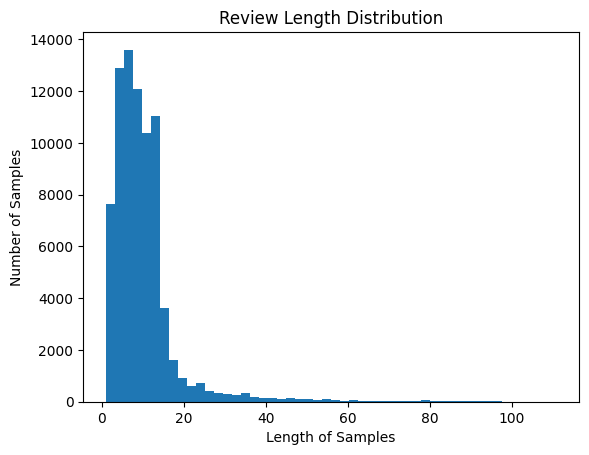

In [35]:
print('리뷰의 최대 길이 :', max(len(review) for review in x_train_sequences))
print('리뷰의 평균 길이 :', sum(map(len, x_train_sequences)) / len(x_train_sequences))

plt.hist([len(review) for review in x_train_sequences], bins=50)
plt.xlabel('Length of Samples')
plt.ylabel('Number of Samples')
plt.title('Review Length Distribution')
plt.show()

In [36]:
below_threshold_len(30, x_train_sequences)
below_threshold_len(40, x_train_sequences)
below_threshold_len(50, x_train_sequences)

전체 샘플 중 길이가 30 이하인 샘플의 비율: 96.85723028278552
전체 샘플 중 길이가 40 이하인 샘플의 비율: 98.21760971007471
전체 샘플 중 길이가 50 이하인 샘플의 비율: 98.89588698778591


* 샘플 중 40 이하인 샘플의 비율이 약 98% 정도로 나와 각 모델들을 비교하는 단계에서는 max_len을 40으로 고정을 하고 실험을 진행했다.

In [37]:
max_len = 40
x_train_padded = pad_sequences(x_train_sequences, maxlen=max_len, padding='post', truncating='post')
x_valid_padded = pad_sequences(x_valid_sequences, maxlen=max_len, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test_sequences, maxlen=max_len, padding='post', truncating='post')

## 2. 실험 1: 기본 모델 아키텍처 탐색
<hr>

* 첫 번째 실험에서는 혐오 표현 분류 문제를 기본적인 접근법들의 성능을 실험했다.
* 이를 위해 RNN 계열, RNN + 어텐션 계열 그리고 CNN 과 RNN을 결합한 하이브리드 계열의 총 11가지 모델 아키텍처를 구현했다.

In [38]:
vocab_size = len(word_to_index)
embedding_dim = 128
hidden_units = 128
num_classes = len(mlb.classes_)  # 8개 클래스

#### Model 1 : 기본 LSTM

In [39]:
inputs = Input(shape=(max_len,), dtype='int32')
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
lstm = LSTM(hidden_units, dropout=0.2)(embedding) 
outputs = Dense(num_classes, activation='sigmoid')(lstm)

model1 = Model(inputs, outputs, name="LSTM_Model")
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1758360273.523590  213752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1758360273.946457  213752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1758360273.947787  213752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/li

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 40, 128)        │     1,971,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,104,201 (8.03 MB)

 Trainable params: 2,104,201 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 2: BiLSTM

In [41]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
bilstm = Bidirectional(LSTM(hidden_units, dropout=0.2))(embedding)
outputs = Dense(num_classes, activation='sigmoid')(bilstm)

model2 = Model(inputs, outputs, name="BiLSTM_Model")
model2.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 40, 128)        │     1,971,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,236,937 (8.53 MB)

 Trainable params: 2,236,937 (8.53 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 3: GRU

In [42]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
gru = GRU(hidden_units, dropout=0.2)(embedding)
outputs = Dense(num_classes, activation='sigmoid')(gru)

model3 = Model(inputs, outputs, name="GRU_Model")
model3.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 40, 128)        │     1,971,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,071,689 (7.90 MB)

 Trainable params: 2,071,689 (7.90 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 4: BiGRU

In [43]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
bigru = Bidirectional(GRU(hidden_units, dropout=0.2))(embedding)
outputs = Dense(num_classes, activation='sigmoid')(bigru)

model4 = Model(inputs, outputs, name="BiGRU_Model")
model4.summary()

Model: "BiGRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 40, 128)        │     1,971,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,913 (8.29 MB)

 Trainable params: 2,171,913 (8.29 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 5: Stacked BiLSTM

In [45]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
bilstm1 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding)
bilstm2 = Bidirectional(LSTM(int(hidden_units/2), dropout=0.2))(bilstm1)
outputs = Dense(num_classes, activation='sigmoid')(bilstm2)

model5 = Model(inputs, outputs, name="Stacked_BiLSTM_Model")
model5.summary()

Model: "Stacked_BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 40, 128)        │     1,971,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 40, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,400,137 (9.16 MB)

 Trainable params: 2,400,137 (9.16 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 6: BiLSTM + Attention

In [46]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
bilstm = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding)
attention = Attention()([bilstm, bilstm])
pool = GlobalAveragePooling1D()(attention)
dense1 = Dense(hidden_units, activation='relu')(pool) # Attention 이후 Dense 추가
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model6 = Model(inputs, outputs, name="BiLSTM_Attention_Model")
model6.summary()

Model: "BiLSTM_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 40, 128)   │  1,971,456 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 40, 256)   │    263,168 │ embedding_5[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 40, 256)   │          0 │ bidirectional_4[… │
│ (Attention)         │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 9)         │      1,161 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,268,681 (8.65 MB)

 Trainable params: 2,268,681 (8.65 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 7: BiGRU + Attention

In [47]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
bigru = Bidirectional(GRU(hidden_units, return_sequences=True, dropout=0.2))(embedding)
attention = Attention()([bigru, bigru])
pool = GlobalAveragePooling1D()(attention)
dense1 = Dense(hidden_units, activation='relu')(pool)
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model7 = Model(inputs, outputs, name="BiGRU_Attention_Model")
model7.summary()

Model: "BiGRU_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 40, 128)   │  1,971,456 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 40, 256)   │    198,144 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 40, 256)   │          0 │ bidirectional_5[… │
│ (Attention)         │                   │            │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 9)         │      1,161 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,203,657 (8.41 MB)

 Trainable params: 2,203,657 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 8: CNN + BiLSTM

In [48]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
cnn_pool = GlobalMaxPooling1D()(conv)
bilstm = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding)
rnn_pool = GlobalAveragePooling1D()(bilstm)
merged = Concatenate()([cnn_pool, rnn_pool])
dense1 = Dense(64, activation='relu')(merged)
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model8 = Model(inputs, outputs, name="CNN_BiLSTM_Model")
model8.summary()

Model: "CNN_BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 40, 128)   │  1,971,456 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 36, 128)   │     82,048 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 40, 256)   │    263,168 │ embedding_7[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ bidirectional_6[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │     24,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 9)         │        585 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,341,897 (8.93 MB)

 Trainable params: 2,341,897 (8.93 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 9: CNN + BiGRU

In [49]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
cnn_pool = GlobalMaxPooling1D()(conv)
bigru = Bidirectional(GRU(hidden_units, return_sequences=True, dropout=0.2))(embedding)
rnn_pool = GlobalAveragePooling1D()(bigru)
merged = Concatenate()([cnn_pool, rnn_pool])
dense1 = Dense(64, activation='relu')(merged)
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model9 = Model(inputs, outputs, name="CNN_BiGRU_Model")
model9.summary()

Model: "CNN_BiGRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 40, 128)   │  1,971,456 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 36, 128)   │     82,048 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 40, 256)   │    198,144 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ bidirectional_7[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     24,640 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 9)         │        585 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,276,873 (8.69 MB)

 Trainable params: 2,276,873 (8.69 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 10: CNN + BiLSTM + Attention

In [50]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
cnn_pool = GlobalMaxPooling1D()(conv)
bilstm = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding)
attention = Attention()([bilstm, bilstm])
rnn_pool = GlobalAveragePooling1D()(attention)
merged = Concatenate()([cnn_pool, rnn_pool])
dense1 = Dense(64, activation='relu')(merged)
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model10 = Model(inputs, outputs, name="CNN_BiLSTM_Attention_Model")
model10.summary()

Model: "CNN_BiLSTM_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 40, 128)   │  1,971,456 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 40, 256)   │    263,168 │ embedding_9[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 128)   │     82,048 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 40, 256)   │          0 │ bidirectional_8[… │
│ (Attention)         │                   │            │ bidirectional_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_2[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     24,640 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 9)         │        585 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,341,897 (8.93 MB)

 Trainable params: 2,341,897 (8.93 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 11: CNN + BiGRU + Attention

In [52]:
inputs = Input(shape=(max_len,))
embedding = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs)
conv = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
cnn_pool = GlobalMaxPooling1D()(conv)
bigru = Bidirectional(GRU(hidden_units, return_sequences=True, dropout=0.2))(embedding)
attention = Attention()([bigru, bigru])
rnn_pool = GlobalAveragePooling1D()(attention)
merged = Concatenate()([cnn_pool, rnn_pool])

dense1 = Dense(64, activation='relu')(merged)
dropout = Dropout(0.5)(dense1)
outputs = Dense(num_classes, activation='sigmoid')(dropout)

model11 = Model(inputs, outputs, name="CNN_BiGRU_Attention_Model")
model11.summary()

Model: "CNN_BiGRU_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 40, 128)   │  1,971,456 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 40, 256)   │    198,144 │ embedding_10[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 128)   │     82,048 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 40, 256)   │          0 │ bidirectional_9[… │
│ (Attention)         │                   │            │ bidirectional_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │     24,640 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 9)         │        585 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,276,873 (8.69 MB)

 Trainable params: 2,276,873 (8.69 MB)

 Non-trainable params: 0 (0.00 B)

* 밑의 함수를 통해 모델과 데이터를 입력받아 전체 실험 과정을 자동화했다.
* 모델 학습부터 최적 가중치를 이용한 평가, 결과 시각화까지 모두 수행한 뒤, 최종 성능 지표를 반환한다.

In [53]:
def run_experiment(model, x_train_padded, y_train, x_valid_padded, y_valid, x_test_padded, y_test, epochs=15, batch_size=64, learning_rate=3e-4):
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
    mc_path = f'best_model_{model.name}.keras'
    mc = ModelCheckpoint(mc_path, monitor='val_loss', mode='min', verbose=1, save_best_only=True)
    
    # 모델 컴파일
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    # 모델 학습 실행
    history = model.fit(x_train_padded, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_valid_padded, y_valid),
                        callbacks=[es, mc],
                        verbose=1)
                        
    # 모델 평가
    print(f"\n--- {model.name} 모델 최종 평가 ---")
    model.load_weights(mc_path)
    y_pred_proba = model.predict(x_test_padded)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # 평가지표 계산
    emr = accuracy_score(y_test, y_pred)
    hl = hamming_loss(y_test, y_pred)
    print(f" 평가 완료 - EMR: {emr:.4f}, Hamming Loss: {hl:.4f}")
    
    # 학습 과정 시각화 
    print(f"\n--- {model.name} 학습 과정 시각화 ---")
    plt.figure(figsize=(12, 5))
    
    # 정확도 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model.name} - Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # 손실 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model.name} - Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # 나중에 결과 종합을 위해 성능 지표와 history 객체를 반환함.
    return {'EMR': emr, 'Hamming Loss': hl, 'history': history}


In [54]:
results = {}

Epoch 1/15
1212/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5342 - loss: 0.3225
Epoch 1: val_loss improved from None to 0.28888, saving model to best_model_LSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5438 - loss: 0.3017 - val_accuracy: 0.5615 - val_loss: 0.2889
Epoch 2/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5475 - loss: 0.2935
Epoch 2: val_loss improved from 0.28888 to 0.22265, saving model to best_model_LSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5555 - loss: 0.2793 - val_accuracy: 0.6107 - val_loss: 0.2226
Epoch 3/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6180 - loss: 0.2162
Epoch 3: val_loss improved from 0.22265 to 0.18753, saving model to best_model_LSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6410 - loss: 0.2085 - val_accuracy: 0.6949 - val_loss: 0.1875
Epoch 4/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7113 - loss: 0.1750
Epoch 

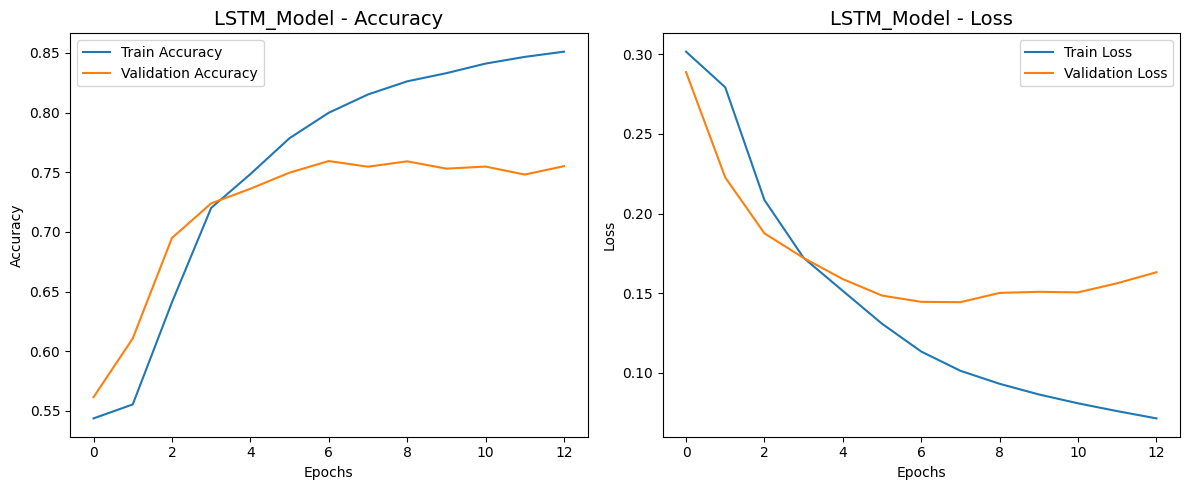

In [55]:
# --- Model 1: LSTM_Model ---
model_name = model1
results[model_name] = run_experiment(model1, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5645 - loss: 0.2883
Epoch 1: val_loss improved from None to 0.15514, saving model to best_model_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6274 - loss: 0.2289 - val_accuracy: 0.7471 - val_loss: 0.1551
Epoch 2/15
1218/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7604 - loss: 0.1395
Epoch 2: val_loss improved from 0.15514 to 0.13122, saving model to best_model_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7679 - loss: 0.1343 - val_accuracy: 0.7684 - val_loss: 0.1312
Epoch 3/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7963 - loss: 0.1112
Epoch 3: val_loss improved from 0.13122 to 0.12707, saving model to best_model_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7945 - loss: 0.1122 - val_accuracy: 0.7742 - val_loss: 0.1271
Epoch 4/15
1217/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8122 - loss: 0.0998

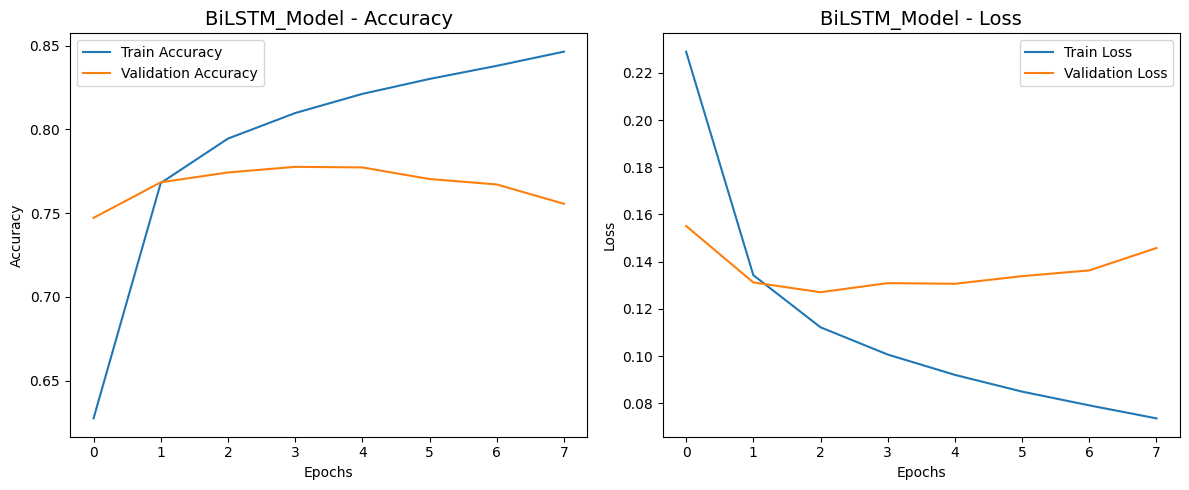

In [56]:
# --- Model 2: BiLSTM_Model ---
model_name = model2
results[model_name] = run_experiment(model2, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5383 - loss: 0.3315
Epoch 1: val_loss improved from None to 0.25820, saving model to best_model_GRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5459 - loss: 0.3028 - val_accuracy: 0.6058 - val_loss: 0.2582
Epoch 2/15
1213/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6509 - loss: 0.2233
Epoch 2: val_loss improved from 0.25820 to 0.17555, saving model to best_model_GRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6856 - loss: 0.2032 - val_accuracy: 0.7267 - val_loss: 0.1755
Epoch 3/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.1623
Epoch 3: val_loss improved from 0.17555 to 0.14986, saving model to best_model_GRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7501 - loss: 0.1562 - val_accuracy: 0.7598 - val_loss: 0.1499
Epoch 4/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7917 - loss: 0.1269
Epoch 4: 

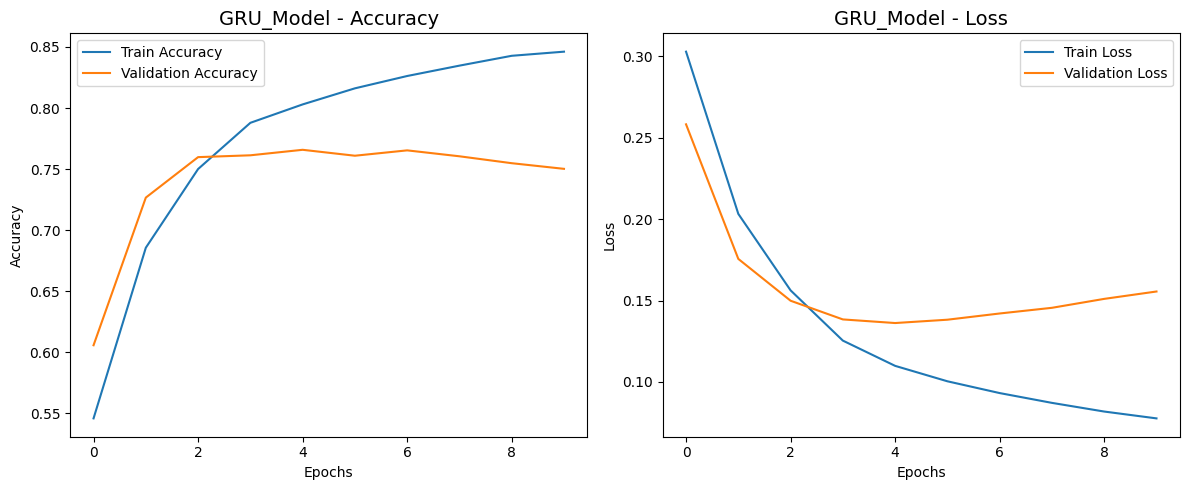

In [57]:
# --- Model 3: GRU_Model ---
model_name = model3
results[model_name] = run_experiment(model3, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5867 - loss: 0.2850
Epoch 1: val_loss improved from None to 0.14582, saving model to best_model_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6585 - loss: 0.2144 - val_accuracy: 0.7576 - val_loss: 0.1458
Epoch 2/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7717 - loss: 0.1324
Epoch 2: val_loss improved from 0.14582 to 0.12962, saving model to best_model_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7725 - loss: 0.1288 - val_accuracy: 0.7727 - val_loss: 0.1296
Epoch 3/15
1218/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7974 - loss: 0.1107
Epoch 3: val_loss improved from 0.12962 to 0.12829, saving model to best_model_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7962 - loss: 0.1104 - val_accuracy: 0.7666 - val_loss: 0.1283
Epoch 4/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8146 - loss: 0.0988
Ep

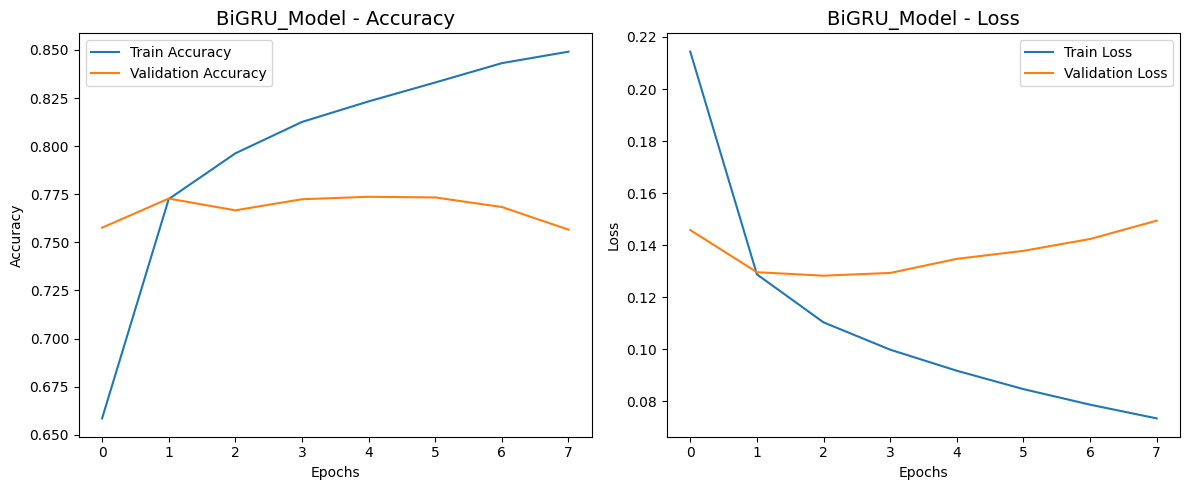

In [58]:
# --- Model 4: BiGRU_Model ---
model_name = model4
results[model_name] = run_experiment(model4, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5619 - loss: 0.2892
Epoch 1: val_loss improved from None to 0.20860, saving model to best_model_Stacked_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.5931 - loss: 0.2470 - val_accuracy: 0.6492 - val_loss: 0.2086
Epoch 2/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6571 - loss: 0.2009
Epoch 2: val_loss improved from 0.20860 to 0.17871, saving model to best_model_Stacked_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6715 - loss: 0.1957 - val_accuracy: 0.7130 - val_loss: 0.1787
Epoch 3/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7245 - loss: 0.1632
Epoch 3: val_loss improved from 0.17871 to 0.15467, saving model to best_model_Stacked_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7286 - loss: 0.1587 - val_accuracy: 0.7321 - val_loss: 0.1547
Epoch 4/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step -

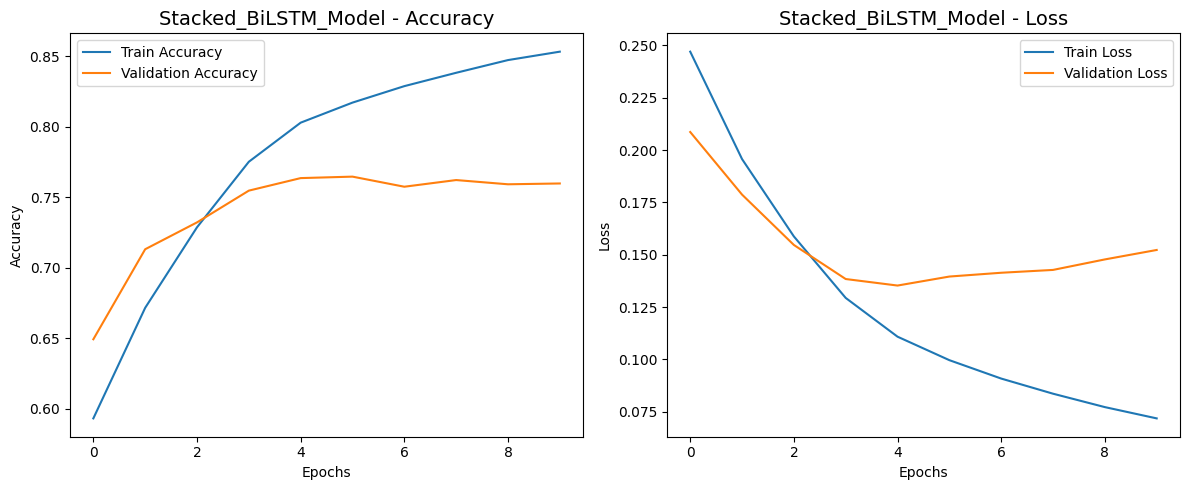

In [59]:
# --- Model 5: Stacked_BiLSTM_Model ---
model_name = model5
results[model_name] = run_experiment(model5, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5081 - loss: 0.3255
Epoch 1: val_loss improved from None to 0.21417, saving model to best_model_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5595 - loss: 0.2712 - val_accuracy: 0.6105 - val_loss: 0.2142
Epoch 2/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6111 - loss: 0.2180
Epoch 2: val_loss improved from 0.21417 to 0.18738, saving model to best_model_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6301 - loss: 0.2115 - val_accuracy: 0.6904 - val_loss: 0.1874
Epoch 3/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7025 - loss: 0.1809
Epoch 3: val_loss improved from 0.18738 to 0.15354, saving model to best_model_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7165 - loss: 0.1732 - val_accuracy: 0.7458 - val_loss: 0.1535
Epoch 4/15
1217/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - a

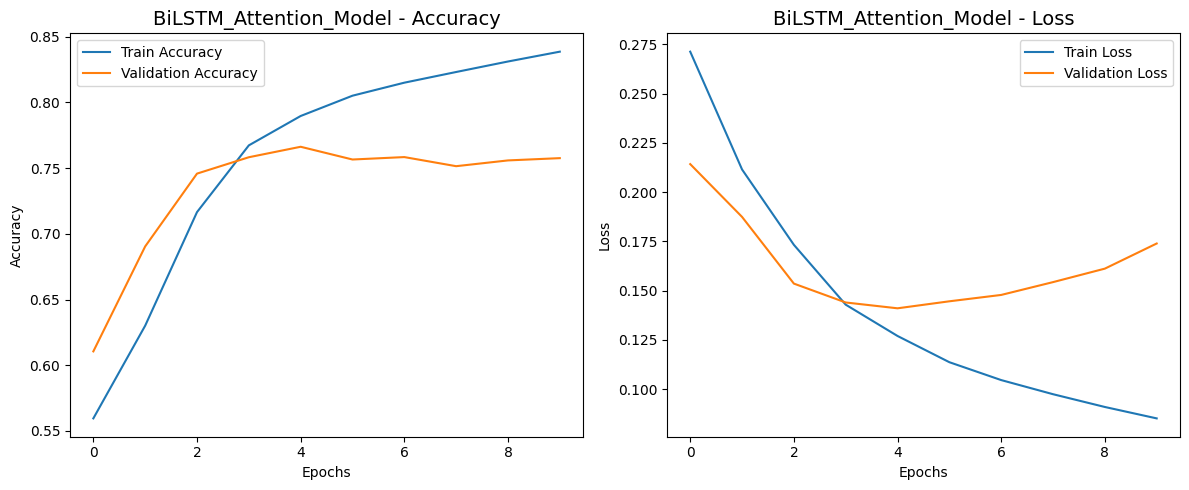

In [60]:
# --- Model 6: BiLSTM_Attention_Model ---
model_name = model6
results[model_name] = run_experiment(model6, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5079 - loss: 0.3331
Epoch 1: val_loss improved from None to 0.21248, saving model to best_model_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5546 - loss: 0.2816 - val_accuracy: 0.6112 - val_loss: 0.2125
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6195 - loss: 0.2169
Epoch 2: val_loss improved from 0.21248 to 0.19307, saving model to best_model_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6386 - loss: 0.2117 - val_accuracy: 0.6783 - val_loss: 0.1931
Epoch 3/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6788 - loss: 0.1902
Epoch 3: val_loss improved from 0.19307 to 0.18136, saving model to best_model_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6841 - loss: 0.1871 - val_accuracy: 0.7054 - val_loss: 0.1814
Epoch 4/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accu

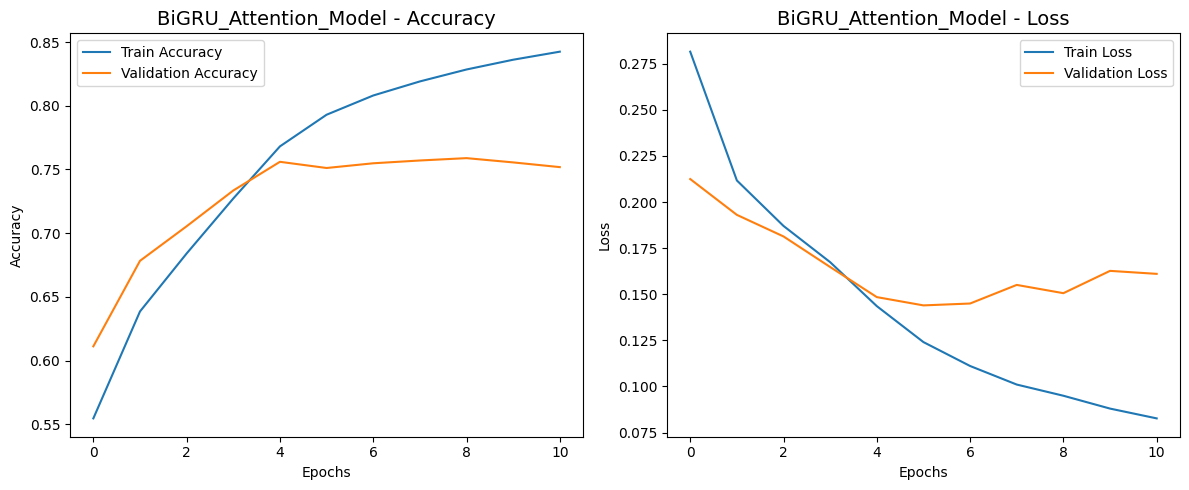

In [61]:
# --- Model 7: BiGRU_Attention_Model ---
model_name = model7
results[model_name] = run_experiment(model7, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
   1/1226 ━━━━━━━━━━━━━━━━━━━━ 58:44 3s/step - accuracy: 0.0625 - loss: 0.6952

W0000 00:00:1758360976.730955  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.747614  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.756046  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.756344  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.757831  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.758037  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.759067  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.760090  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360976.760324  214223 gp

1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4835 - loss: 0.3433

W0000 00:00:1758360985.314507  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.314712  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.314863  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315017  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315164  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315328  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315488  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315647  214223 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758360985.315813  214223 gp


Epoch 1: val_loss improved from None to 0.16365, saving model to best_model_CNN_BiLSTM_Model.keras


...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5845 - loss: 0.2697 - val_accuracy: 0.7304 - val_loss: 0.1636
Epoch 2/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7329 - loss: 0.1688
Epoch 2: val_loss improved from 0.16365 to 0.13251, saving model to best_model_CNN_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7444 - loss: 0.1605 - val_accuracy: 0.7738 - val_loss: 0.1325
Epoch 3/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7787 - loss: 0.1349
Epoch 3: val_loss improved from 0.13251 to 0.13034, saving model to best_model_CNN_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7801 - loss: 0.1339 - val_accuracy: 0.7758 - val_loss: 0.1303
Epoch 4/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8012 - loss: 0.1180
Epoch 4: val_loss improved from 0.13034 to 0.12940, saving model to best_model_CNN_BiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7993 - loss: 0

W0000 00:00:1758361058.950525  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.950744  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.950918  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951081  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951235  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951403  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951569  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951738  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361058.951909  214225 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


W0000 00:00:1758361060.260152  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.260362  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.260515  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.260687  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.260844  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.261012  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.261181  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.261346  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361060.261508  214234 gp

 평가 완료 - EMR: 0.7431, Hamming Loss: 0.0470

--- CNN_BiLSTM_Model 학습 과정 시각화 ---


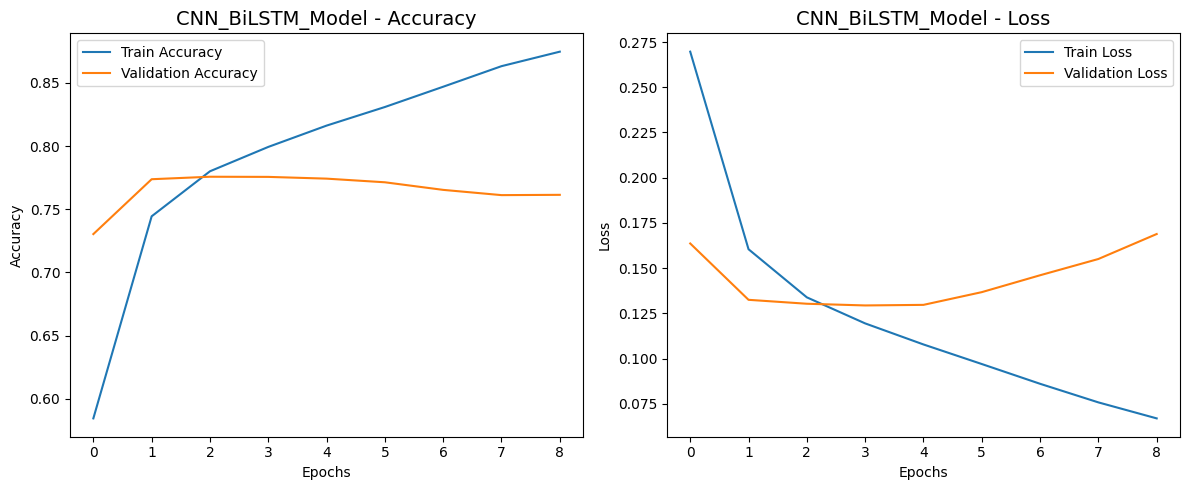

In [62]:
# --- Model 8: CNN_BiLSTM_Model ---
model_name = model8
results[model_name] = run_experiment(model8, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5190 - loss: 0.3316
Epoch 1: val_loss improved from None to 0.15491, saving model to best_model_CNN_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6047 - loss: 0.2590 - val_accuracy: 0.7453 - val_loss: 0.1549
Epoch 2/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7369 - loss: 0.1652
Epoch 2: val_loss improved from 0.15491 to 0.13290, saving model to best_model_CNN_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7470 - loss: 0.1586 - val_accuracy: 0.7739 - val_loss: 0.1329
Epoch 3/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7784 - loss: 0.1352
Epoch 3: val_loss improved from 0.13290 to 0.12754, saving model to best_model_CNN_BiGRU_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7781 - loss: 0.1350 - val_accuracy: 0.7774 - val_loss: 0.1275
Epoch 4/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8016 - lo

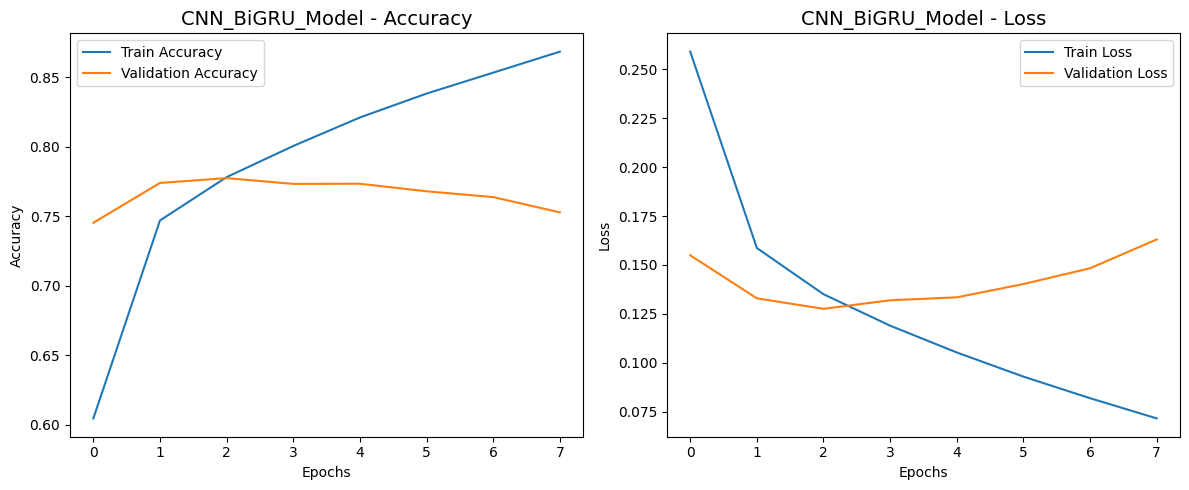

In [63]:
# --- Model 9: CNN_BiGRU_Model ---
model_name = model9
results[model_name] = run_experiment(model9, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1219/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5332 - loss: 0.3319
Epoch 1: val_loss improved from None to 0.16746, saving model to best_model_CNN_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.6074 - loss: 0.2622 - val_accuracy: 0.7403 - val_loss: 0.1675
Epoch 2/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7364 - loss: 0.1757
Epoch 2: val_loss improved from 0.16746 to 0.13577, saving model to best_model_CNN_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7467 - loss: 0.1671 - val_accuracy: 0.7727 - val_loss: 0.1358
Epoch 3/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7736 - loss: 0.1406
Epoch 3: val_loss improved from 0.13577 to 0.12950, saving model to best_model_CNN_BiLSTM_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7787 - loss: 0.1380 - val_accuracy: 0.7777 - val_loss: 0.1295
Epoch 4/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0

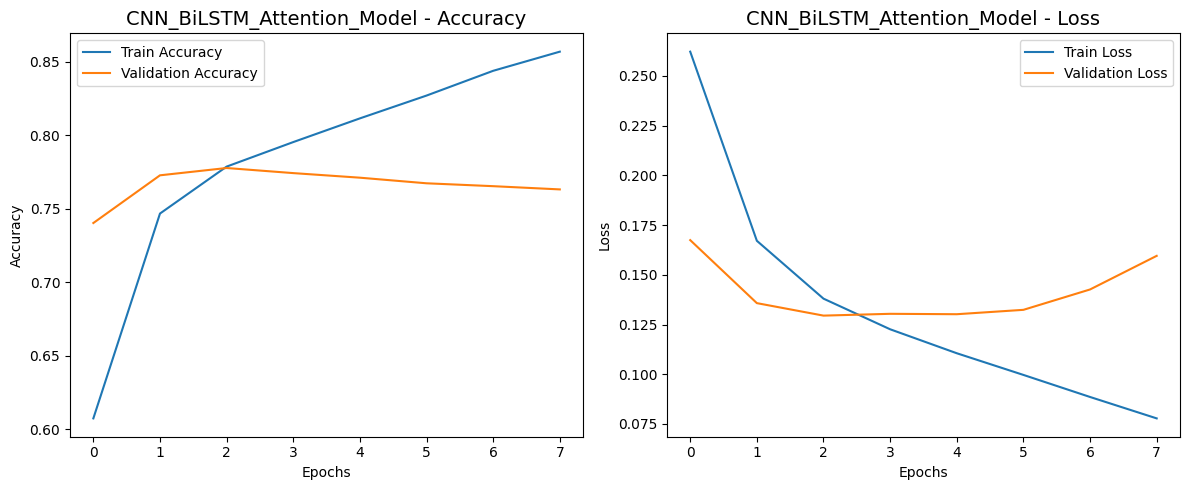

In [64]:
# --- Model 10: CNN_BiLSTM_Attention_Model ---
model_name = model10
results[model_name] = run_experiment(model10, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5268 - loss: 0.3328
Epoch 1: val_loss improved from None to 0.15569, saving model to best_model_CNN_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6142 - loss: 0.2610 - val_accuracy: 0.7447 - val_loss: 0.1557
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7422 - loss: 0.1623
Epoch 2: val_loss improved from 0.15569 to 0.13026, saving model to best_model_CNN_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7507 - loss: 0.1549 - val_accuracy: 0.7726 - val_loss: 0.1303
Epoch 3/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7813 - loss: 0.1310
Epoch 3: val_loss improved from 0.13026 to 0.12833, saving model to best_model_CNN_BiGRU_Attention_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7809 - loss: 0.1299 - val_accuracy: 0.7769 - val_loss: 0.1283
Epoch 4/15
1220/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

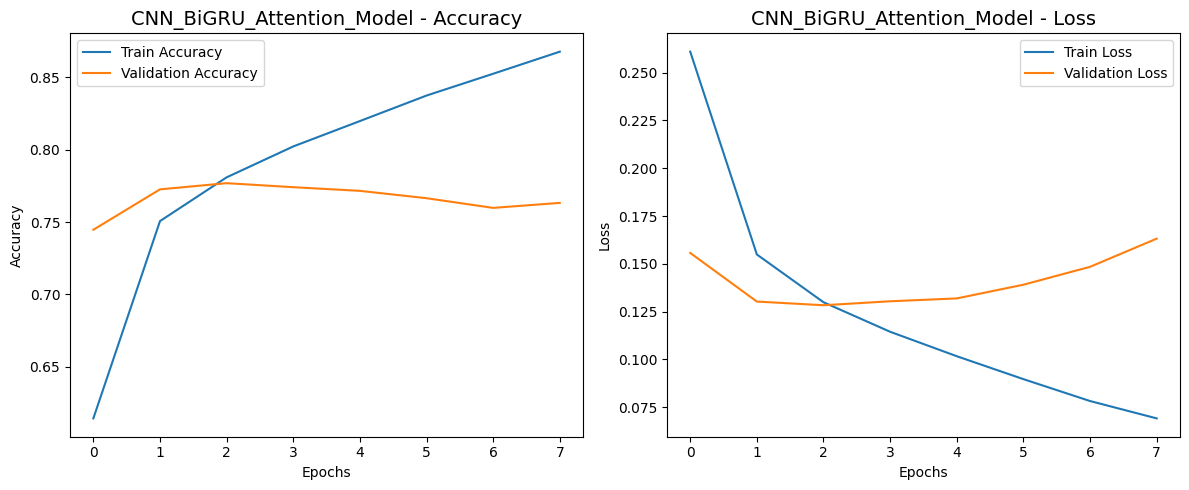

In [65]:
# --- Model 11: CNN_BiGRU_Attention_Model ---
model_name = model11
results[model_name] = run_experiment(model11, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

In [66]:
results

{<Functional name=LSTM_Model, built=True>: {'EMR': 0.7199167244968772,
  'Hamming Loss': 0.05225794844115455,
  'history': <keras.src.callbacks.history.History at 0x7ff59315f290>},
 <Functional name=BiLSTM_Model, built=True>: {'EMR': 0.7183900069396253,
  'Hamming Loss': 0.04861850052689747,
  'history': <keras.src.callbacks.history.History at 0x7ff6bc75c3d0>},
 <Functional name=GRU_Model, built=True>: {'EMR': 0.727411519777932,
  'Hamming Loss': 0.0504536458734932,
  'history': <keras.src.callbacks.history.History at 0x7ff592c8b050>},
 <Functional name=BiGRU_Model, built=True>: {'EMR': 0.7118204950266019,
  'Hamming Loss': 0.04904515896882309,
  'history': <keras.src.callbacks.history.History at 0x7ff58c4344d0>},
 <Functional name=Stacked_BiLSTM_Model, built=True>: {'EMR': 0.7235715938006014,
  'Hamming Loss': 0.05006811113681343,
  'history': <keras.src.callbacks.history.History at 0x7ff58c180210>},
 <Functional name=BiLSTM_Attention_Model, built=True>: {'EMR': 0.728059218135554,
  '

* 실험1 성능평가 결과

In [67]:
clean_results = {
    model.name: {
        'EMR': metrics['EMR'],
        'Hamming Loss': metrics['Hamming Loss']
    }
    for model, metrics in results.items()
}

df_results = pd.DataFrame.from_dict(clean_results, orient='index')
df_results.reset_index(inplace=True)
df_results.rename(columns={'index': 'Model Name'}, inplace=True)

df_sorted = df_results.sort_values(by='EMR', ascending=False)

styled_df = df_sorted.style.format({
    'EMR': '{:.4f}',
    'Hamming Loss': '{:.4f}'
}).hide()

styled_df

Model Name,EMR,Hamming Loss
CNN_BiLSTM_Model,0.7431,0.0470
CNN_BiGRU_Attention_Model,0.7415,0.0474
CNN_BiGRU_Model,0.7341,0.0474
CNN_BiLSTM_Attention_Model,0.7307,0.0477
BiLSTM_Attention_Model,0.7281,0.0511
GRU_Model,0.7274,0.0505
Stacked_BiLSTM_Model,0.7236,0.0501
LSTM_Model,0.7199,0.0523
BiLSTM_Model,0.7184,0.0486
BiGRU_Model,0.7118,0.0490


## 3. 실험 2: 개선 모델 구현 및 평가
<hr>

* 첫 번째 실험 결과, CNN과 RNN을 같이 사용하는 하이브리드 모델이 가장 우수한 성능을 보인다.
* 두 번째 실험에서는 이 하이브리드 구조를 더 깊고 정교하게 개선한 모델로 평가를 진행했다.
* 이를 위해 CNN 계층을 다중 커널 방식으로 확장하고, BiLSTM/BiGUR 계층을 2단으로 깊게 쌓는 기법들을 적용했다.

#### Model 12: Stacked CNN + Stacked BiLSTM
* CNN과 BiLSTM을 각각 2층으로 깊게 쌓아 구현한 모델

In [69]:
inputs_12 = Input(shape=(max_len,))
embedding_12 = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs_12)

conv1_12 = Conv1D(filters=128, kernel_size=5, padding='same', activation='relu')(embedding_12)
conv2_12 = Conv1D(filters=128, kernel_size=5, activation='relu')(conv1_12)
cnn_features_12 = GlobalMaxPooling1D()(conv2_12)

bilstm1_12 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding_12)
bilstm2_12 = Bidirectional(LSTM(int(hidden_units/2)))(bilstm1_12)

merged_12 = Concatenate()([cnn_features_12, bilstm2_12])
dense1_12 = Dense(128, activation='relu')(merged_12)
dropout_12 = Dropout(0.5)(dense1_12)
outputs_12 = Dense(num_classes, activation='sigmoid')(dropout_12)

model12 = Model(inputs_12, outputs_12, name="StackedCNN_StackedBiLSTM_Model")
model12.summary()

Model: "StackedCNN_StackedBiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 40, 128)   │  1,971,456 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 40, 128)   │     82,048 │ embedding_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 36, 128)   │     82,048 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_12    │ (None, 40, 256)   │    263,168 │ embedding_12[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_13    │ (None, 128)       │    164,352 │ bidirectional_12… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ bidirectional_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     32,896 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 9)         │      1,161 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,597,129 (9.91 MB)

 Trainable params: 2,597,129 (9.91 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 13: Multi-Kernel CNN + Stacked BiGRU
* 멀티-커널 CNN과 2층 BiGRU를 결합해 구현한 모델

In [70]:
inputs_13 = Input(shape=(max_len,))
embedding_13 = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs_13)

pooled_outputs_13 = []
for kernel_size in [3, 4, 5]:
    conv_13 = Conv1D(filters=128, kernel_size=kernel_size, activation='relu')(embedding_13)
    pool_13 = GlobalMaxPooling1D()(conv_13)
    pooled_outputs_13.append(pool_13)
cnn_features_13 = Concatenate()(pooled_outputs_13)

bigru1_13 = Bidirectional(GRU(hidden_units, return_sequences=True, dropout=0.2))(embedding_13)
bigru2_13 = Bidirectional(GRU(int(hidden_units/2)))(bigru1_13)

merged_13 = Concatenate()([cnn_features_13, bigru2_13])
dense1_13 = Dense(128, activation='relu')(merged_13)
dropout_13 = Dropout(0.5)(dense1_13)
outputs_13 = Dense(num_classes, activation='sigmoid')(dropout_13)

model13 = Model(inputs_13, outputs_13, name="MultiKernelCNN_StackedBiGRU")
model13.summary()

Model: "MultiKernelCNN_StackedBiGRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 40, 128)   │  1,971,456 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 38, 128)   │     49,280 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 37, 128)   │     65,664 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 36, 128)   │     82,048 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_8[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_9[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_10[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_14    │ (None, 40, 256)   │    198,144 │ embedding_13[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_15    │ (None, 128)       │    123,648 │ bidirectional_14… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 512)       │          0 │ concatenate_6[0]… │
│ (Concatenate)       │                   │            │ bidirectional_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │     65,664 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 9)         │      1,161 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,557,065 (9.75 MB)

 Trainable params: 2,557,065 (9.75 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 14: Multi-Kernel CNN + Stacked BiLSTM
* 멀티-커널 CNN과 2층 BiLSTM를 결합한 모델

In [71]:
inputs_14 = Input(shape=(max_len,))
embedding_14 = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs_14)

pooled_outputs_14 = []
for kernel_size in [3, 4, 5]:
    conv_14 = Conv1D(filters=128, kernel_size=kernel_size, activation='relu')(embedding_14)
    pool_14 = GlobalMaxPooling1D()(conv_14)
    pooled_outputs_14.append(pool_14)
cnn_features_14 = Concatenate()(pooled_outputs_14)

bilstm1_14 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding_14)
bilstm2_14 = Bidirectional(LSTM(int(hidden_units/2)))(bilstm1_14)

merged_14 = Concatenate()([cnn_features_14, bilstm2_14])
dense1_14 = Dense(128, activation='relu')(merged_14)
dropout_14 = Dropout(0.5)(dense1_14)
outputs_14 = Dense(num_classes, activation='sigmoid')(dropout_14)

model14 = Model(inputs_14, outputs_14, name="MultiKernelCNN_StackedBiLSTM")
model14.summary()

Model: "MultiKernelCNN_StackedBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 40, 128)   │  1,971,456 │ input_layer_14[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 38, 128)   │     49,280 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 37, 128)   │     65,664 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 36, 128)   │     82,048 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_11[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_12[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_13[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_16    │ (None, 40, 256)   │    263,168 │ embedding_14[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_17    │ (None, 128)       │    164,352 │ bidirectional_16… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 512)       │          0 │ concatenate_8[0]… │
│ (Concatenate)       │                   │            │ bidirectional_17… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 128)       │     65,664 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 9)         │      1,161 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,662,793 (10.16 MB)

 Trainable params: 2,662,793 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

#### Model 15: Multi-Kernel CNN + Stacked BiLSTM + Attention
* 멀티-커널 CNN과 2층 BiLSTM 구조에 어텐션 메커니즘을 추가한 모델

In [72]:
inputs_15 = Input(shape=(max_len,))
embedding_15 = Embedding(vocab_size, embedding_dim, input_length=max_len)(inputs_15)

pooled_outputs_15 = []
for kernel_size in [3, 4, 5]:
    conv_15 = Conv1D(filters=128, kernel_size=kernel_size, activation='relu')(embedding_15)
    pool_15 = GlobalMaxPooling1D()(conv_15)
    pooled_outputs_15.append(pool_15)
cnn_features_15 = Concatenate()(pooled_outputs_15)

bilstm1_15 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding_15)
bilstm2_15 = Bidirectional(LSTM(int(hidden_units/2), return_sequences=True))(bilstm1_15)
attention_15 = Attention()([bilstm2_15, bilstm2_15])
rnn_features_15 = GlobalAveragePooling1D()(attention_15)

merged_15 = Concatenate()([cnn_features_15, rnn_features_15])
dense1_15 = Dense(128, activation='relu')(merged_15)
dropout_15 = Dropout(0.5)(dense1_15)
outputs_15 = Dense(num_classes, activation='sigmoid')(dropout_15)

model15 = Model(inputs_15, outputs_15, name="MultiKernelCNN_StackedBiLSTM_Attention")
model15.summary()

Model: "MultiKernelCNN_StackedBiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 40, 128)   │  1,971,456 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_18    │ (None, 40, 256)   │    263,168 │ embedding_15[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 38, 128)   │     49,280 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 37, 128)   │     65,664 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 36, 128)   │     82,048 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_19    │ (None, 40, 128)   │    164,352 │ bidirectional_18… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_14[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_15[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_16[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 40, 128)   │          0 │ bidirectional_19… │
│ (Attention)         │                   │            │ bidirectional_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_4[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 512)       │          0 │ concatenate_10[0… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     65,664 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 9)         │      1,161 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,662,793 (10.16 MB)

 Trainable params: 2,662,793 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
results2 = {}

Epoch 1/15
  15/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3293 - loss: 0.6635

W0000 00:00:1758361436.952269  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.952513  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.952703  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.952886  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.953074  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.953244  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.953421  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.953611  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361436.953824  214233 gp

1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5520 - loss: 0.3044

W0000 00:00:1758361450.840400  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.840613  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.840781  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.840939  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.841099  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.841266  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.841425  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.841592  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361450.841755  214234 gp


Epoch 1: val_loss improved from None to 0.15509, saving model to best_model_StackedCNN_StackedBiLSTM_Model.keras


...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6206 - loss: 0.2403 - val_accuracy: 0.7424 - val_loss: 0.1551
Epoch 2/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7579 - loss: 0.1526
Epoch 2: val_loss improved from 0.15509 to 0.12977, saving model to best_model_StackedCNN_StackedBiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7626 - loss: 0.1470 - val_accuracy: 0.7711 - val_loss: 0.1298
Epoch 3/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7956 - loss: 0.1187
Epoch 3: val_loss improved from 0.12977 to 0.12496, saving model to best_model_StackedCNN_StackedBiLSTM_Model.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7943 - loss: 0.1178 - val_accuracy: 0.7761 - val_loss: 0.1250
Epoch 4/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8166 - loss: 0.1005
Epoch 4: val_loss did not improve from 0.12496
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8153 - loss: 0.1005 - val_accura

W0000 00:00:1758361551.845850  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.846767  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.847568  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.848426  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.849235  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.849425  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.849613  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.849796  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361551.849994  214224 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


W0000 00:00:1758361554.010397  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.010607  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.010776  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.010952  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.011127  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.011303  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.011481  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.011660  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361554.011845  214232 gp

 평가 완료 - EMR: 0.7474, Hamming Loss: 0.0462

--- StackedCNN_StackedBiLSTM_Model 학습 과정 시각화 ---


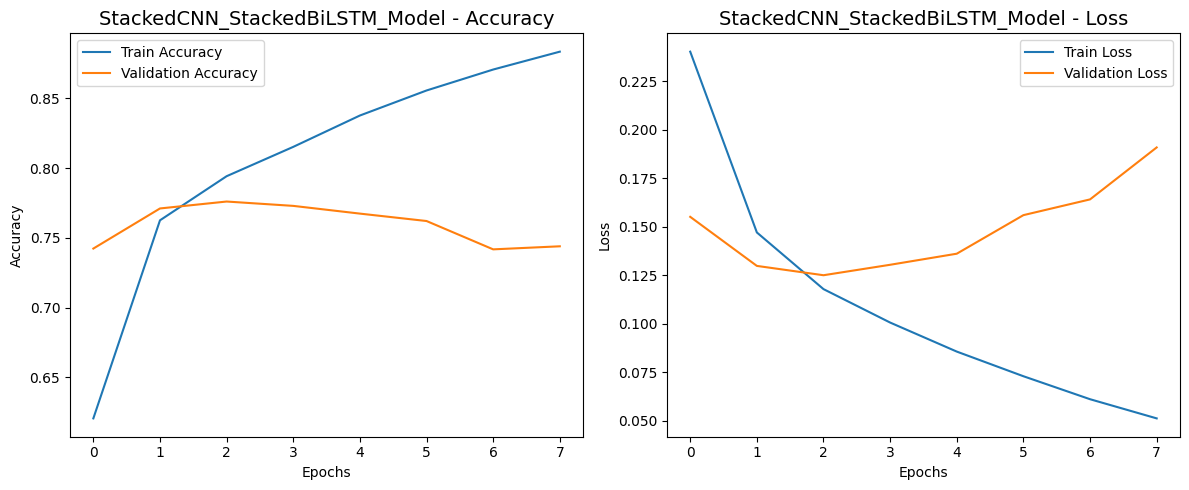

In [74]:
# --- Model 12: StackedCNN_StackedBiLSTM_Model ---
model_name = model12.name
results2[model_name] = run_experiment(model12, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
  11/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3952 - loss: 0.6668

W0000 00:00:1758361561.233563  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.233839  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.234084  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.234310  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.234551  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.235126  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.235388  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.235728  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361561.235961  214224 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5895 - loss: 0.2926

W0000 00:00:1758361575.784662  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.784911  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785101  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785261  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785408  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785573  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785732  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.785897  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361575.786051  214224 gp


Epoch 1: val_loss improved from None to 0.14132, saving model to best_model_MultiKernelCNN_StackedBiGRU.keras


...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.6593 - loss: 0.2235 - val_accuracy: 0.7650 - val_loss: 0.1413
Epoch 2/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7722 - loss: 0.1367
Epoch 2: val_loss improved from 0.14132 to 0.12231, saving model to best_model_MultiKernelCNN_StackedBiGRU.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7751 - loss: 0.1324 - val_accuracy: 0.7758 - val_loss: 0.1223
Epoch 3/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8018 - loss: 0.1113
Epoch 3: val_loss improved from 0.12231 to 0.12047, saving model to best_model_MultiKernelCNN_StackedBiGRU.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8009 - loss: 0.1116 - val_accuracy: 0.7778 - val_loss: 0.1205
Epoch 4/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8239 - loss: 0.0958
Epoch 4: val_loss did not improve from 0.12047
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8223 - loss: 0.0964 - val_accuracy: 0.

W0000 00:00:1758361681.222205  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.223198  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.223899  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.224602  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.225276  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.225453  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.225625  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.225795  214229 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361681.225962  214229 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


W0000 00:00:1758361683.587070  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.587325  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.587527  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.587725  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.587907  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.588112  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.588308  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.588497  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758361683.588710  214235 gp

 평가 완료 - EMR: 0.7509, Hamming Loss: 0.0455

--- MultiKernelCNN_StackedBiGRU 학습 과정 시각화 ---


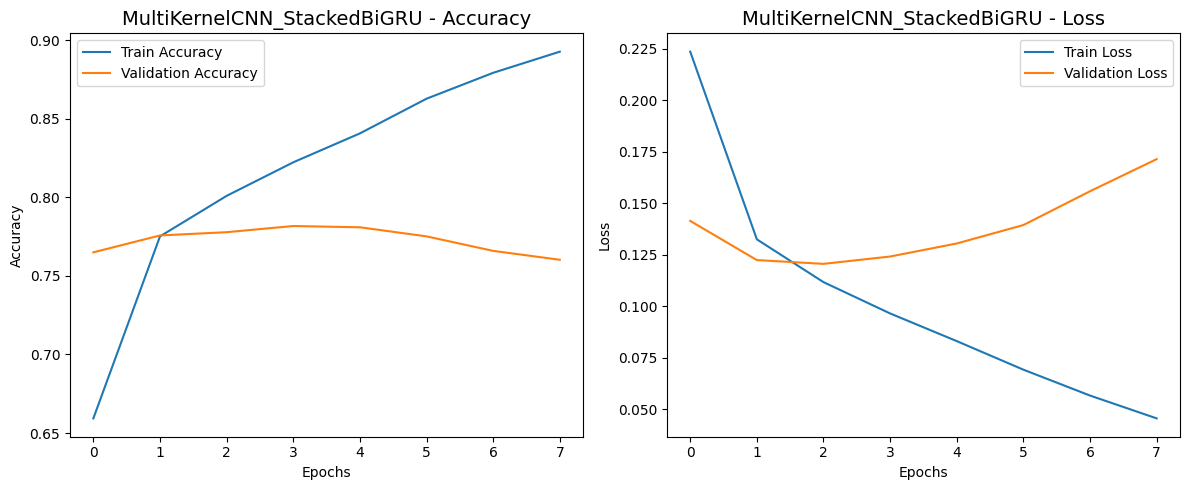

In [75]:
# --- Model 13: MultiKernelCNN_StackedBiGRU ---
model_name = model13.name
results2[model_name] = run_experiment(model13, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5878 - loss: 0.2932
Epoch 1: val_loss improved from None to 0.13600, saving model to best_model_MultiKernelCNN_StackedBiLSTM.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.6642 - loss: 0.2208 - val_accuracy: 0.7628 - val_loss: 0.1360
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7715 - loss: 0.1357
Epoch 2: val_loss improved from 0.13600 to 0.12269, saving model to best_model_MultiKernelCNN_StackedBiLSTM.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7736 - loss: 0.1323 - val_accuracy: 0.7719 - val_loss: 0.1227
Epoch 3/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7997 - loss: 0.1106
Epoch 3: val_loss improved from 0.12269 to 0.12135, saving model to best_model_MultiKernelCNN_StackedBiLSTM.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7984 - loss: 0.1115 - val_accuracy: 0.7739 - val_loss: 0.1214
Epoch 4/15
1223/1226 ━━━━━━━━━━

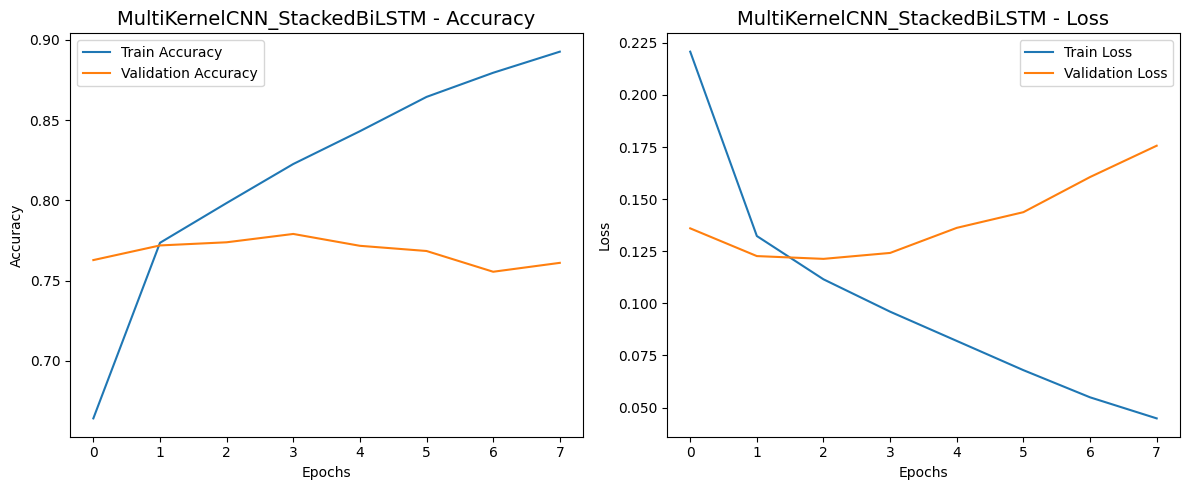

In [76]:
# --- Model 14: MultiKernelCNN_StackedBiLSTM ---
model_name = model14.name
results2[model_name] = run_experiment(model14, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

Epoch 1/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5486 - loss: 0.3035
Epoch 1: val_loss improved from None to 0.13924, saving model to best_model_MultiKernelCNN_StackedBiLSTM_Attention.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.6556 - loss: 0.2276 - val_accuracy: 0.7656 - val_loss: 0.1392
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7679 - loss: 0.1407
Epoch 2: val_loss improved from 0.13924 to 0.12277, saving model to best_model_MultiKernelCNN_StackedBiLSTM_Attention.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7721 - loss: 0.1362 - val_accuracy: 0.7749 - val_loss: 0.1228
Epoch 3/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8012 - loss: 0.1142
Epoch 3: val_loss improved from 0.12277 to 0.12248, saving model to best_model_MultiKernelCNN_StackedBiLSTM_Attention.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8002 - loss: 0.1136 - val_accuracy: 0.7770 - val_loss: 0.1225
E

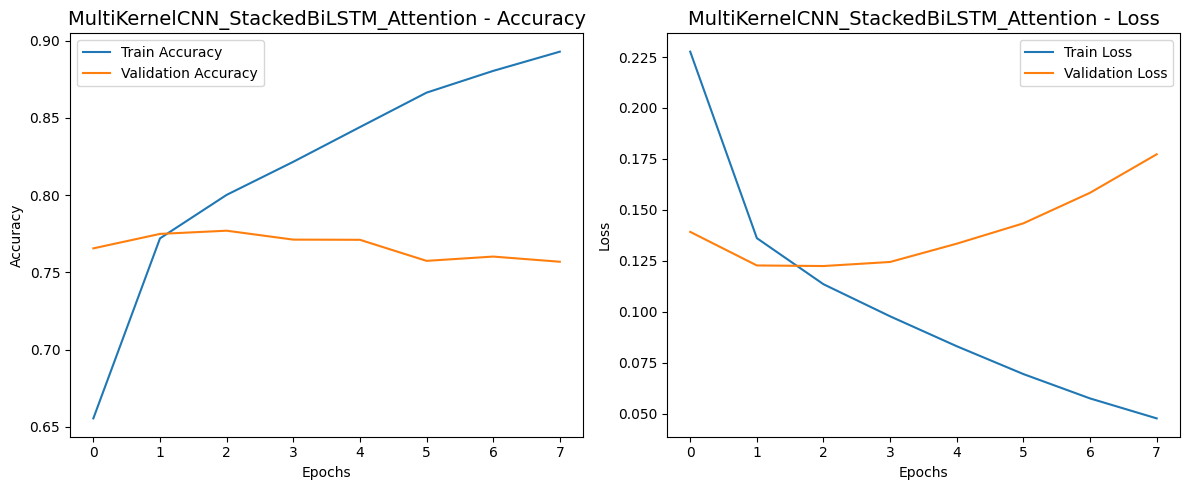

In [77]:
# --- Model 15: MultiKernelCNN_StackedBiLSTM_Attention ---
model_name = model15.name
results2[model_name] = run_experiment(model15, 
                                     x_train_padded, y_train, 
                                     x_valid_padded, y_valid, 
                                     x_test_padded, y_test)

In [78]:
results2

{'StackedCNN_StackedBiLSTM_Model': {'EMR': 0.7474439046958131,
  'Hamming Loss': 0.046197342380548484,
  'history': <keras.src.callbacks.history.History at 0x7feefb441310>},
 'MultiKernelCNN_StackedBiGRU': {'EMR': 0.7508674531575295,
  'Hamming Loss': 0.04546225614927905,
  'history': <keras.src.callbacks.history.History at 0x7fee3d675990>},
 'MultiKernelCNN_StackedBiLSTM': {'EMR': 0.7520240573675688,
  'Hamming Loss': 0.04559590819132804,
  'history': <keras.src.callbacks.history.History at 0x7fee27f1b7d0>},
 'MultiKernelCNN_StackedBiLSTM_Attention': {'EMR': 0.7482766597270414,
  'Hamming Loss': 0.04624874701210579,
  'history': <keras.src.callbacks.history.History at 0x7fee373453d0>}}

* 실험2 성능평가 결과

In [79]:
clean_results2 = {
    model_name: {
        'EMR': metrics['EMR'],
        'Hamming Loss': metrics['Hamming Loss']
    }
    for model_name, metrics in results2.items()
}

df_results2 = pd.DataFrame.from_dict(clean_results2, orient='index')
df_results2.reset_index(inplace=True)
df_results2.rename(columns={'index': 'Model Name'}, inplace=True)

df_sorted2 = df_results2.sort_values(by='EMR', ascending=False)

styled_df2 = df_sorted2.style.format({
    'EMR': '{:.4f}',
    'Hamming Loss': '{:.4f}'
}).hide()

styled_df2

Model Name,EMR,Hamming Loss
MultiKernelCNN_StackedBiLSTM,0.7520,0.0456
MultiKernelCNN_StackedBiGRU,0.7509,0.0455
MultiKernelCNN_StackedBiLSTM_Attention,0.7483,0.0462
StackedCNN_StackedBiLSTM_Model,0.7474,0.0462


## 4. 실험 3: 최적 모델 하이퍼파라미터 튜닝
<hr>

* 이전 두 번의 실험을 통해 MultiKernelCNN_StackedBiLSTM이 두 개의 평가지표에서 우수한 성능을 보이는 것을 확인했다.
* 실험 3에서는 이 모델의 성능을 올리기위해 max_len, learning_rate를 조정하며 실험했다.

#### 하이퍼파라미터 튜닝1 : max_len 조정

In [80]:
results3 = {}

Epoch 1/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5474 - loss: 0.3033

W0000 00:00:1758362009.770519  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.770730  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.770902  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771064  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771229  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771399  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771581  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771759  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362009.771938  214231 gp


Epoch 1: val_loss improved from None to 0.14103, saving model to best_model_MultiKernelCNN_StackedBiLSTM_15.keras


W0000 00:00:1758362010.828939  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.829069  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.829280  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.829621  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.829771  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.830030  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.830257  214224 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.830493  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362010.830717  214224 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6493 - loss: 0.2269 - val_accuracy: 0.7566 - val_loss: 0.1410
Epoch 2/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7640 - loss: 0.1415
Epoch 2: val_loss improved from 0.14103 to 0.12639, saving model to best_model_MultiKernelCNN_StackedBiLSTM_15.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7675 - loss: 0.1374 - val_accuracy: 0.7647 - val_loss: 0.1264
Epoch 3/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7939 - loss: 0.1161
Epoch 3: val_loss improved from 0.12639 to 0.12547, saving model to best_model_MultiKernelCNN_StackedBiLSTM_15.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7921 - loss: 0.1158 - val_accuracy: 0.7789 - val_loss: 0.1255
Epoch 4/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8121 - loss: 0.0999
Epoch 4: val_loss did not improve from 0.12547
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8118 - loss: 0.1009 - val_accuracy

W0000 00:00:1758362095.656416  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.656873  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.657254  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.657668  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.658063  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.658241  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.658410  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.658584  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362095.658750  214226 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


W0000 00:00:1758362097.414741  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.414968  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415127  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415303  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415474  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415646  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415800  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.415964  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362097.416132  214226 gp

 평가 완료 - EMR: 0.7438, Hamming Loss: 0.0472

--- MultiKernelCNN_StackedBiLSTM_15 학습 과정 시각화 ---


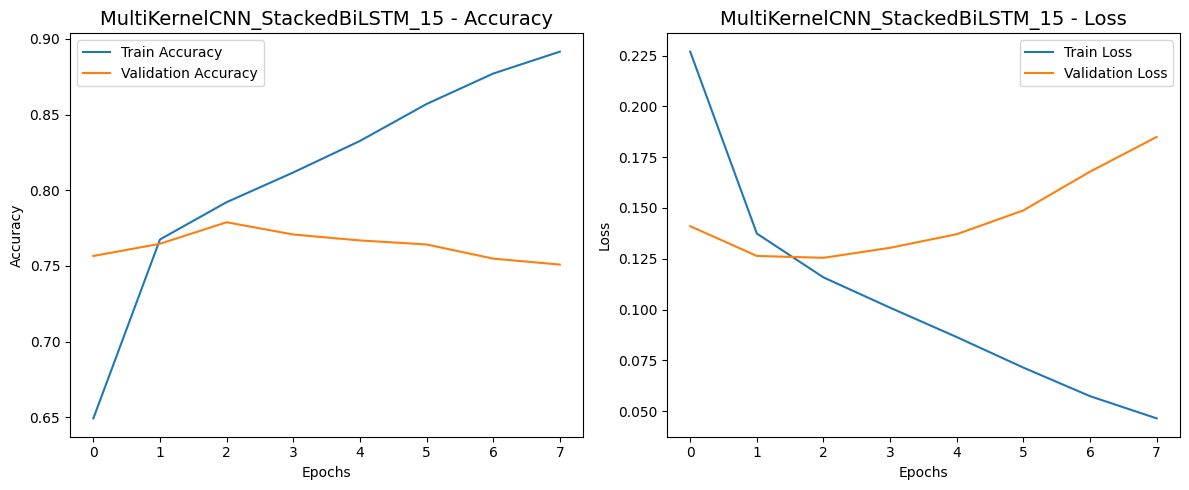

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
   6/1226 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.0748 - loss: 0.6952      

W0000 00:00:1758362103.663864  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664097  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664269  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664443  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664620  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664791  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.664968  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.665140  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362103.665315  214226 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5594 - loss: 0.3084

W0000 00:00:1758362115.841204  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.841415  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.841575  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.841745  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.841898  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.842060  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.842226  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.842388  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362115.842549  214235 gp

...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6480 - loss: 0.2346 - val_accuracy: 0.7655 - val_loss: 0.1471
Epoch 2/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7655 - loss: 0.1457
Epoch 2: val_loss improved from 0.14709 to 0.12635, saving model to best_model_MultiKernelCNN_StackedBiLSTM_20.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7686 - loss: 0.1407 - val_accuracy: 0.7792 - val_loss: 0.1264
Epoch 3/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7936 - loss: 0.1184
Epoch 3: val_loss improved from 0.12635 to 0.12450, saving model to best_model_MultiKernelCNN_StackedBiLSTM_20.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7916 - loss: 0.1190 - val_accuracy: 0.7725 - val_loss: 0.1245
Epoch 4/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8150 - loss: 0.1033
Epoch 4: val_loss did not improve from 0.12450
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8129 - loss: 0.1043 - val_accuracy

W0000 00:00:1758362202.175411  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.175882  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.176380  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.176879  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.177057  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.177228  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.177416  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.177591  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362202.177762  214232 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


W0000 00:00:1758362204.065479  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.065725  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.065991  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.066288  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.066583  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.066863  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.067074  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.067256  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362204.067424  214233 gp

 평가 완료 - EMR: 0.7441, Hamming Loss: 0.0467

--- MultiKernelCNN_StackedBiLSTM_20 학습 과정 시각화 ---


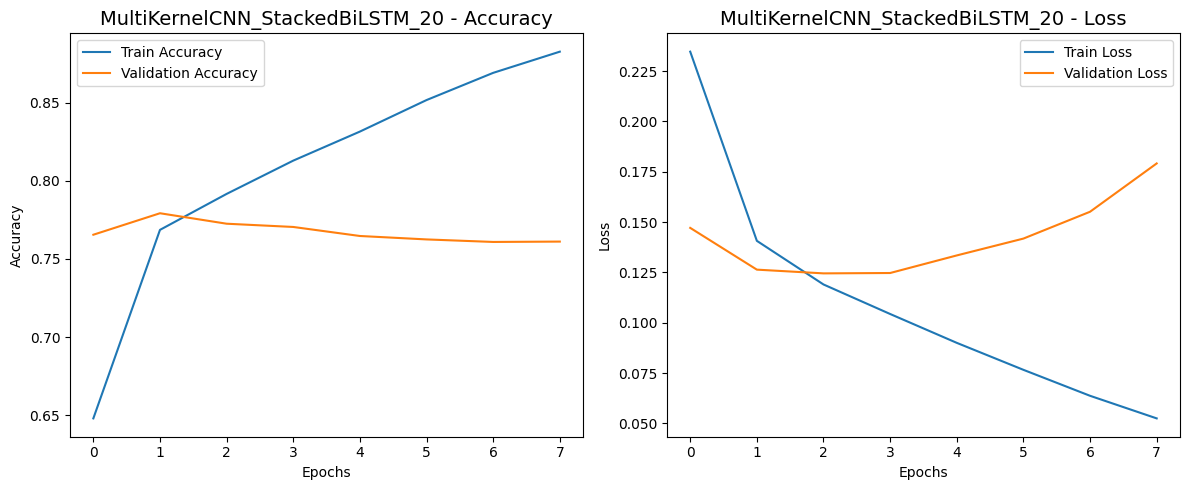

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
  11/1226 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.1159 - loss: 0.6625 

W0000 00:00:1758362219.893469  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.893706  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.893897  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894074  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894247  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894416  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894606  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894781  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362219.894954  214232 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5610 - loss: 0.2935

W0000 00:00:1758362233.174735  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.174840  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.175118  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.175311  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.175514  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.175656  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.175892  214232 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.176009  214226 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362233.176252  214232 gp

...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6544 - loss: 0.2236 - val_accuracy: 0.7642 - val_loss: 0.1359
Epoch 2/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7732 - loss: 0.1353
Epoch 2: val_loss improved from 0.13585 to 0.12312, saving model to best_model_MultiKernelCNN_StackedBiLSTM_30.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7729 - loss: 0.1331 - val_accuracy: 0.7741 - val_loss: 0.1231
Epoch 3/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8008 - loss: 0.1126
Epoch 3: val_loss did not improve from 0.12312
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7990 - loss: 0.1125 - val_accuracy: 0.7756 - val_loss: 0.1238
Epoch 4/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8258 - loss: 0.0949
Epoch 4: val_loss did not improve from 0.12312
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8210 - loss: 0.0968 - val_accuracy: 0.7721 - val_loss: 0.1258
Epoch 5/15
1222/1226 ━━━━━━━━━━━━━━━━━

W0000 00:00:1758362318.521513  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.522043  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.522531  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.523122  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.523673  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.523840  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.523996  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.524164  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362318.524325  214235 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


W0000 00:00:1758362320.592590  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.592820  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.592981  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.593165  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.593344  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.593515  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.593682  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.593848  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362320.594014  214235 gp

 평가 완료 - EMR: 0.7403, Hamming Loss: 0.0467

--- MultiKernelCNN_StackedBiLSTM_30 학습 과정 시각화 ---


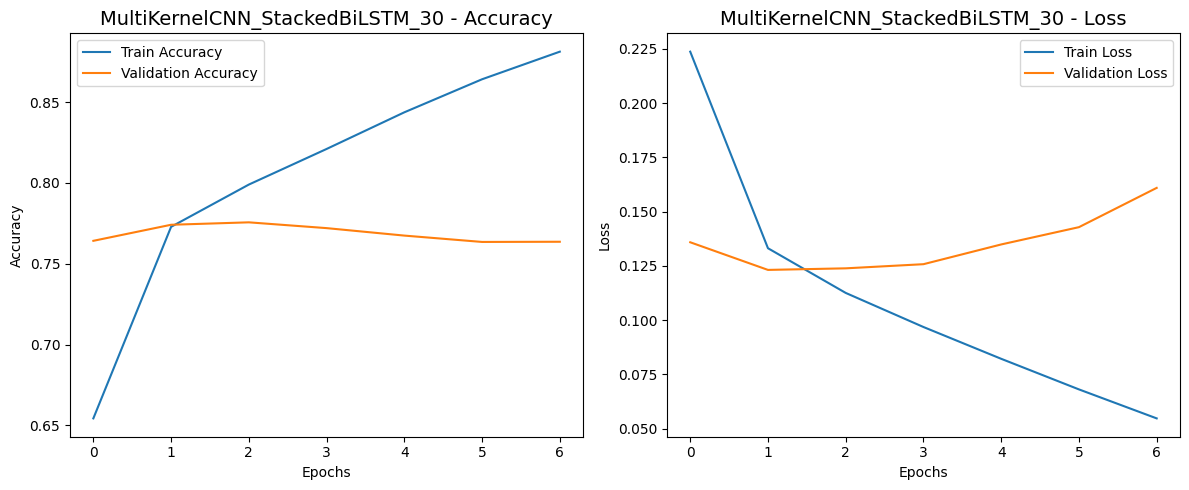

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
   5/1226 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.0766 - loss: 0.6908  

W0000 00:00:1758362330.240271  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.240516  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.240721  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.240911  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.241080  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.241253  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.241432  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.241611  214227 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362330.241774  214227 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5440 - loss: 0.3011

W0000 00:00:1758362346.743824  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.743914  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.744177  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.744371  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.744504  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.744704  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.744896  214234 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.745087  214225 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362346.745297  214234 gp

...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6522 - loss: 0.2239 - val_accuracy: 0.7644 - val_loss: 0.1361
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7694 - loss: 0.1368
Epoch 2: val_loss improved from 0.13607 to 0.12280, saving model to best_model_MultiKernelCNN_StackedBiLSTM_50.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.7739 - loss: 0.1321 - val_accuracy: 0.7766 - val_loss: 0.1228
Epoch 3/15
1225/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8029 - loss: 0.1126
Epoch 3: val_loss improved from 0.12280 to 0.12055, saving model to best_model_MultiKernelCNN_StackedBiLSTM_50.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.7999 - loss: 0.1126 - val_accuracy: 0.7839 - val_loss: 0.1206
Epoch 4/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8234 - loss: 0.0961
Epoch 4: val_loss did not improve from 0.12055
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8210 - loss: 0.0978 - val_accu

W0000 00:00:1758362466.105922  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.106140  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.106319  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.106495  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.106667  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.106845  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.107023  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.107197  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362466.107365  214233 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


W0000 00:00:1758362468.593303  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.593527  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.593714  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.593886  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.594058  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.594239  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.594416  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.594596  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362468.594763  214231 gp

 평가 완료 - EMR: 0.7553, Hamming Loss: 0.0453

--- MultiKernelCNN_StackedBiLSTM_50 학습 과정 시각화 ---


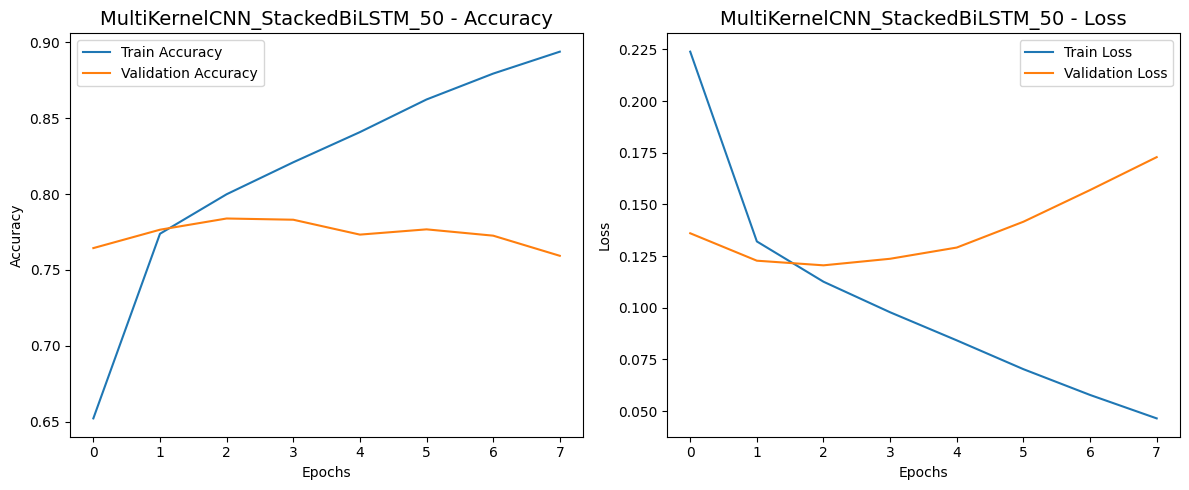

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


   4/1226 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.0941 - loss: 0.6896  

W0000 00:00:1758362477.522752  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523003  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523208  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523408  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523588  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523771  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.523960  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.524148  214233 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362477.524329  214233 gp

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5614 - loss: 0.2931

...

1226/1226 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6596 - loss: 0.2208 - val_accuracy: 0.7669 - val_loss: 0.1393
Epoch 2/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7700 - loss: 0.1377
Epoch 2: val_loss improved from 0.13928 to 0.12311, saving model to best_model_MultiKernelCNN_StackedBiLSTM_100.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.7722 - loss: 0.1340 - val_accuracy: 0.7761 - val_loss: 0.1231
Epoch 3/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7996 - loss: 0.1132
Epoch 3: val_loss improved from 0.12311 to 0.12219, saving model to best_model_MultiKernelCNN_StackedBiLSTM_100.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.7972 - loss: 0.1130 - val_accuracy: 0.7788 - val_loss: 0.1222
Epoch 4/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8183 - loss: 0.0977
Epoch 4: val_loss did not improve from 0.12219
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8172 - loss: 0.0985 - val_ac

W0000 00:00:1758362661.857917  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.859014  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.860065  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.861386  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.863227  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.863394  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.863568  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.863761  214231 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362661.863940  214231 gp

676/676 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


W0000 00:00:1758362665.448915  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.449205  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.449458  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.449678  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.449849  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.450013  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.450180  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.450340  214235 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1758362665.450497  214235 gp

 평가 완료 - EMR: 0.7497, Hamming Loss: 0.0459

--- MultiKernelCNN_StackedBiLSTM_100 학습 과정 시각화 ---


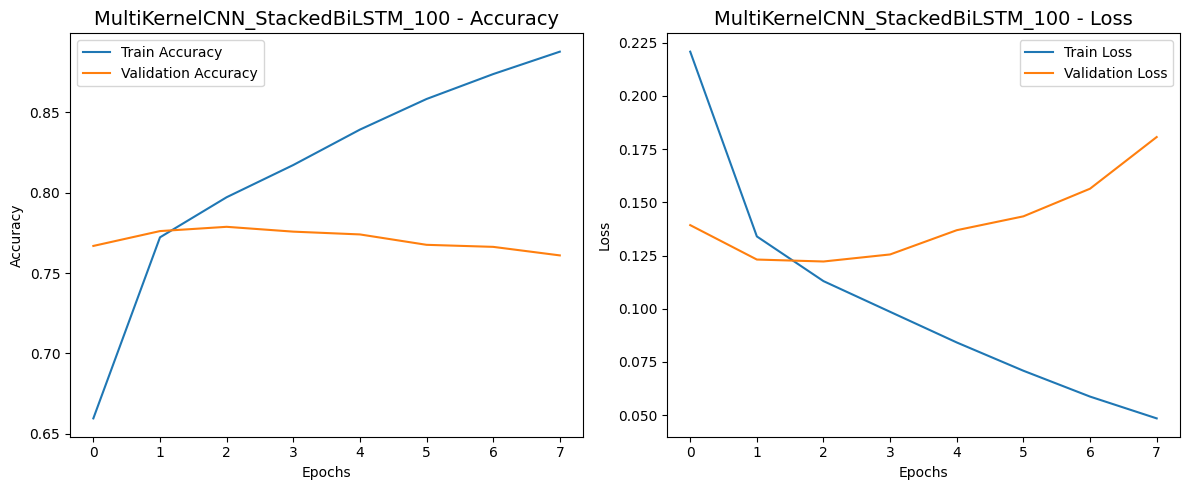

In [82]:
max_len_candidates = [15 ,20 , 30, 50, 100]

for length in max_len_candidates:
    K.clear_session()
    
    x_train_padded_new = pad_sequences(x_train_sequences, maxlen=length, padding='post', truncating='post')
    x_valid_padded_new = pad_sequences(x_valid_sequences, maxlen=length, padding='post', truncating='post')
    x_test_padded_new = pad_sequences(x_test_sequences, maxlen=length, padding='post', truncating='post')
    
    inputs = Input(shape=(length,)) 
    embedding_layer = Embedding(vocab_size, embedding_dim, input_length=length)(inputs)
    
    pooled_outputs = []
    for kernel_size in [3, 4, 5]:
        conv = Conv1D(filters=128, kernel_size=kernel_size, activation='relu')(embedding_layer)
        pool = GlobalMaxPooling1D()(conv)
        pooled_outputs.append(pool)
    cnn_features = Concatenate()(pooled_outputs)

    bilstm1 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding_layer)
    bilstm2 = Bidirectional(LSTM(int(hidden_units/2)))(bilstm1)

    merged = Concatenate()([cnn_features, bilstm2])
    dense1 = Dense(128, activation='relu')(merged)
    dropout = Dropout(0.5)(dense1)
    outputs = Dense(num_classes, activation='sigmoid')(dropout)
    

    model_clone = Model(inputs, outputs, name=f"MultiKernelCNN_StackedBiLSTM_{length}") 
    
    results3[model_clone.name] = run_experiment(model_clone, 
                                               x_train_padded_new, y_train, 
                                               x_valid_padded_new, y_valid, 
                                               x_test_padded_new, y_test)

In [83]:
results3

{'MultiKernelCNN_StackedBiLSTM_15': {'EMR': 0.7438352995604904,
  'Hamming Loss': 0.047174030380137254,
  'history': <keras.src.callbacks.history.History at 0x7feef9aca610>},
 'MultiKernelCNN_StackedBiLSTM_20': {'EMR': 0.7441128845708999,
  'Hamming Loss': 0.0467422314750559,
  'history': <keras.src.callbacks.history.History at 0x7fee243b92d0>},
 'MultiKernelCNN_StackedBiLSTM_30': {'EMR': 0.7403192227619708,
  'Hamming Loss': 0.04669596730665433,
  'history': <keras.src.callbacks.history.History at 0x7fed607a7f90>},
 'MultiKernelCNN_StackedBiLSTM_50': {'EMR': 0.7553088133240805,
  'Hamming Loss': 0.045272059012517026,
  'history': <keras.src.callbacks.history.History at 0x7fed61efb910>},
 'MultiKernelCNN_StackedBiLSTM_100': {'EMR': 0.7497108489474902,
  'Hamming Loss': 0.045873493201737475,
  'history': <keras.src.callbacks.history.History at 0x7fee5f80ded0>}}

* 실험3 성능평가 결과(수정 값 : max_len)

In [84]:
clean_results3 = {
    model_name: {
        'EMR': metrics['EMR'],
        'Hamming Loss': metrics['Hamming Loss']
    }
    for model_name, metrics in results3.items()
}

df_results3 = pd.DataFrame.from_dict(clean_results3, orient='index')
df_results3.reset_index(inplace=True)
df_results3.rename(columns={'index': 'Model Name'}, inplace=True)

df_sorted3 = df_results3.sort_values(by='EMR', ascending=False)

styled_df3 = df_sorted3.style.format({
    'EMR': '{:.4f}',
    'Hamming Loss': '{:.4f}'
}).hide()

styled_df3

Model Name,EMR,Hamming Loss
MultiKernelCNN_StackedBiLSTM_50,0.7553,0.0453
MultiKernelCNN_StackedBiLSTM_100,0.7497,0.0459
MultiKernelCNN_StackedBiLSTM_20,0.7441,0.0467
MultiKernelCNN_StackedBiLSTM_15,0.7438,0.0472
MultiKernelCNN_StackedBiLSTM_30,0.7403,0.0467


#### 하이퍼파라미터 튜닝2 : learning_rate 조정
* 실험은 max_len조정에서 가장 EMR값인 좋았던 50으로 두고 진행했다.

In [85]:
best_max_len = 50
x_train_padded_best = pad_sequences(x_train_sequences, maxlen=best_max_len, padding='post', truncating='post')
x_valid_padded_best = pad_sequences(x_valid_sequences, maxlen=best_max_len, padding='post', truncating='post')
x_test_padded_best = pad_sequences(x_test_sequences, maxlen=best_max_len, padding='post', truncating='post')

In [86]:
learning_rate_candidates = [5e-4, 1e-4] 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5967 - loss: 0.2706
Epoch 1: val_loss improved from None to 0.12588, saving model to best_model_MKCNN_StackedBiLSTM_lr0.0005.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.6861 - loss: 0.1995 - val_accuracy: 0.7766 - val_loss: 0.1259
Epoch 2/15
1221/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7865 - loss: 0.1246
Epoch 2: val_loss improved from 0.12588 to 0.11918, saving model to best_model_MKCNN_StackedBiLSTM_lr0.0005.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7858 - loss: 0.1229 - val_accuracy: 0.7831 - val_loss: 0.1192
Epoch 3/15
1222/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8191 - loss: 0.0992
Epoch 3: val_loss did not improve from 0.11918
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8153 - loss: 0.1006 - val_accuracy: 0.7786 - val_loss: 0.1229
Epoch 4/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8476 - loss: 0.0785
Epoch 4: 

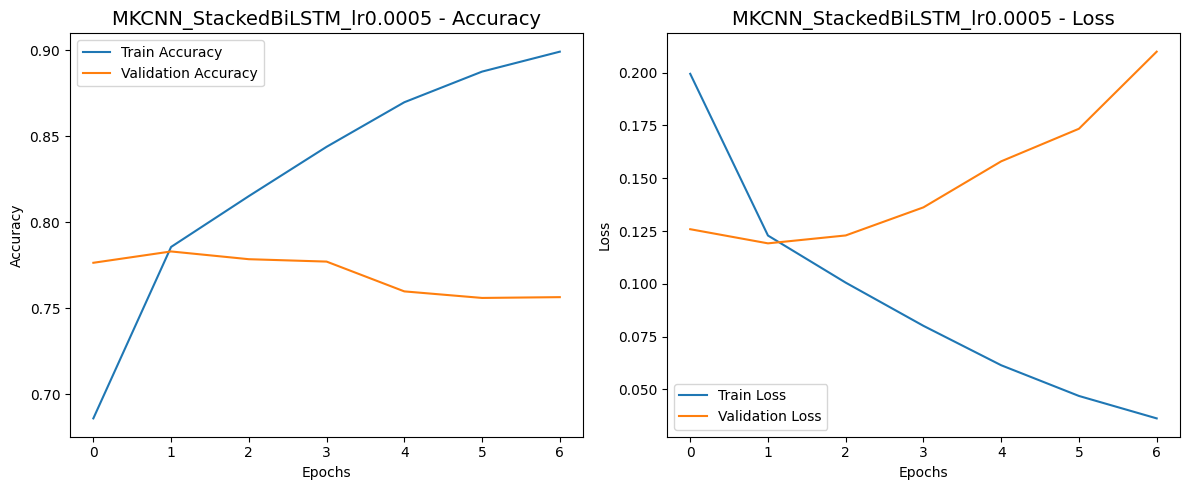

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
1224/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5233 - loss: 0.3566
Epoch 1: val_loss improved from None to 0.19703, saving model to best_model_MKCNN_StackedBiLSTM_lr0.0001.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.5689 - loss: 0.2893 - val_accuracy: 0.6915 - val_loss: 0.1970
Epoch 2/15
1223/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6936 - loss: 0.1976
Epoch 2: val_loss improved from 0.19703 to 0.15026, saving model to best_model_MKCNN_StackedBiLSTM_lr0.0001.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7149 - loss: 0.1848 - val_accuracy: 0.7573 - val_loss: 0.1503
Epoch 3/15
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7666 - loss: 0.1483
Epoch 3: val_loss improved from 0.15026 to 0.13344, saving model to best_model_MKCNN_StackedBiLSTM_lr0.0001.keras
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7681 - loss: 0.1448 - val_accuracy: 0.7696 - val_loss: 0.1334
Epoch 4/15
1224/1226 ━━━━━━━━━━

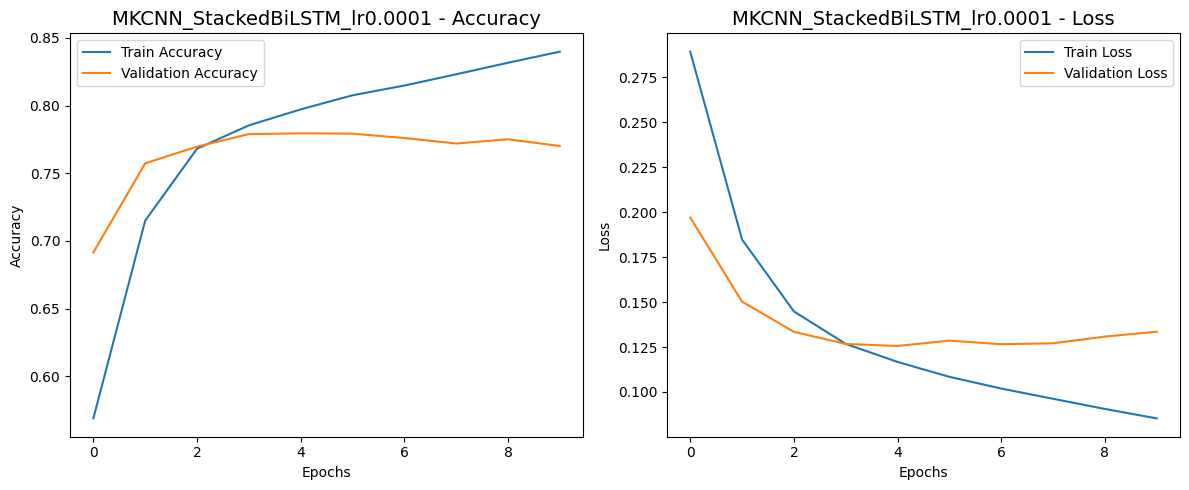

In [87]:
for lr in learning_rate_candidates:
    K.clear_session()
    inputs = Input(shape=(best_max_len,))
    embedding_layer = Embedding(vocab_size, embedding_dim, input_length=best_max_len)(inputs)
    
    pooled_outputs = []
    for kernel_size in [3, 4, 5]:
        conv = Conv1D(filters=128, kernel_size=kernel_size, activation='relu')(embedding_layer)
        pool = GlobalMaxPooling1D()(conv)
        pooled_outputs.append(pool)
        
    cnn_features = Concatenate()(pooled_outputs)
    
    bilstm1 = Bidirectional(LSTM(hidden_units, return_sequences=True, dropout=0.2))(embedding_layer)
    bilstm2 = Bidirectional(LSTM(int(hidden_units/2)))(bilstm1)
    
    merged = Concatenate()([cnn_features, bilstm2])
    dense1 = Dense(128, activation='relu')(merged)
    dropout = Dropout(0.5)(dense1)
    outputs = Dense(num_classes, activation='sigmoid')(dropout)
    model_clone = Model(inputs, outputs, name=f"MKCNN_StackedBiLSTM_lr{lr}")
    

    results3[model_clone.name] = run_experiment(model_clone, 
                                               x_train_padded_best, y_train, 
                                               x_valid_padded_best, y_valid, 
                                               x_test_padded_best, y_test,
                                               learning_rate=lr)

* 실험3 성능평가 결과(수정 값 : learning_rate)

In [88]:
lr_experiment_keys = [
    'MKCNN_StackedBiLSTM_lr0.0005',     # lr = 5e-4
    'MKCNN_StackedBiLSTM_lr0.0001'      # lr = 1e-4
]

lr_results_filtered = {
    model_name: {
        'EMR': metrics['EMR'],
        'Hamming Loss': metrics['Hamming Loss']
    }
    for model_name, metrics in results3.items()
    if model_name in lr_experiment_keys
}

df_lr = pd.DataFrame.from_dict(lr_results_filtered, orient='index')
df_lr.reset_index(inplace=True)
df_lr.rename(columns={'index': 'Model Name'}, inplace=True)

df_lr_sorted = df_lr.sort_values(by='EMR', ascending=False)

styled_df_lr = df_lr_sorted.style.format({
    'EMR': '{:.4f}',
    'Hamming Loss': '{:.4f}'
}).hide()

styled_df_lr

Model Name,EMR,Hamming Loss
MKCNN_StackedBiLSTM_lr0.0005,0.7568,0.0445
MKCNN_StackedBiLSTM_lr0.0001,0.7414,0.0466


## 5. 최종 결과 종합 및 분석
<hr>

| Model Name | EMR | Hamming Loss |
|:---|:---:|:---:|
|CNN_BiLSTM_Model	|0.7431|	0.0470
|CNN_BiGRU_Attention_Model	|0.7415|	0.0474
|CNN_BiGRU_Model	|0.7341|	0.0474
|CNN_BiLSTM_Attention_Model	|0.7307	|0.0477
|BiLSTM_Attention_Model|	0.7281	|0.0511
|GRU_Model	|0.7274|	0.0505
|Stacked_BiLSTM_Model	|0.7236	|0.0501
|LSTM_Model|	0.7199	|0.0523
|BiLSTM_Model	|0.7184	|0.0486
|BiGRU_Model	|0.7118	|0.0490
|BiGRU_Attention_Model	|0.7109|	0.0511

---
* 실험 1의 결과, CNN_BiLSTM_Model이 실험한 11개의 모델 중 가장 우수한 성능을 기록했다.
* 전반적으로 CNN과 RNN을 결합한 하이브리드 모델들이 단일 RNN 계열 모델 대비 더 높은 성능을 보이는 것을 확인할 수 있다.
* 한 가지 예상과 달랐던 점은, 어텐션을 추가하는 것이 반드시 성능 향상으로 이어지지 않았다는 점이다.
>예를 들어, CNN_BiLSTM_Model(EMR:0.7431)은 어텐션을 추가한 CNN_BiLSTM_Attention_Model(EMR:0.7307) 보다 오히려 높은 성능을 보여준다.
---

* 실험 1의 결과를 바탕으로 성능이 좋았던 하이브리드 구조를 멀티커널, Stacked RNN 기법을 적용해 개선해본 결과이다.
  
| Model Name | EMR | Hamming Loss |
|:---|:---:|:---:|
|MultiKernelCNN_StackedBiLSTM	|0.7520	|0.0456
|MultiKernelCNN_StackedBiGRU	|0.7509	|0.0455
|MultiKernelCNN_StackedBiLSTM_Attention	|0.7483	|0.0462
|StackedCNN_StackedBiLSTM_Model	|0.7474	|0.0462


---
* 실험2의 결과로는 MultiKernelCNN_StackedBiLSTM이 EMR 0.7220로 성능이 가장 좋은 것을 볼 수 있다.
* 이러한 결과의 원인은 CNN구조를 단일 커널 방식이 아닌 멀티커널 방식으로 학습을 진행해 혐오 표현의 패턴을 좀 더 효과적으로 학습한 것 같다.
* 추가로 RNN 계층을 2단으로 깊게 쌓아 더 복잡하고 추상적인 문맥 정보를 학습할 수 있었던 거 같다.
* 전반적으로 실험1의 결과보다 성능이 좋아진 것을 볼 수 있다.
---

| Model Name | EMR | Hamming Loss |
|:---|:---:|:---:|
|MultiKernelCNN_StackedBiLSTM_50	|0.7553	|0.0453
|MultiKernelCNN_StackedBiLSTM_100	|0.7497	|0.0459
|MultiKernelCNN_StackedBiLSTM_20	|0.7441	|0.0467
|MultiKernelCNN_StackedBiLSTM_15	|0.7438	|0.0472
|MultiKernelCNN_StackedBiLSTM_30	|0.7403	|0.0467

---
* 위의 표는 기존 실험에서는 시퀀스 길이를 40으로 맞추고 실험을 했지만 최적의 길이를 찾기위해 추가 실험해서 나온 결과이다.
* 데이터를 분석한 결과, 문장의 평균 길이는 10이며, 전체 데이터의 약 97%가 30 이하의 짧은 길이를 갖는다는 특징이 있었다.
* 실험 결과, 시퀀스 길이를 50으로 설정했을때 가장 좋은 성능을 기록했다.
* 너무 문장의 길이를 길게 잡아도 과도한 패딩(padding)이 노이즈로 작용해 성능이 떨어지고, 반대로 너무 짧게 잡으면 핵심 정보를 담은 문장이 잘려나가 성능이 하락하는 것을 확인했다.
---

| Model Name | EMR | Hamming Loss |
|:---|:---:|:---:|
MKCNN_StackedBiLSTM_lr0.0005	|0.7568	|0.0445
MKCNN_StackedBiLSTM_lr0.0001	|0.7414	|0.0466

---
* 실험 결과, 학습률을 0.0005로 설정했을 때 EMR 0.7568, Hamming Loss 0.0445로 가장 우수한 성능을 달성했다.

## 6. 결론 및 느낀점
<hr>

#### 결론
모든 실험을 종합한 결과, Multi-kernel CNN과 Stacked-BiLSTM 구조에 시퀀스 길이 50, 학습률 0.0005를 적용한 모델이 최종적으로 가장 우수한 성능을 기록했다.

| Model Name | EMR | Hamming Loss |
|:---|:---:|:---:|
MKCNN_StackedBiLSTM_lr0.0005	|0.7568	|0.0445


#### 느낀점
* 이번 실험을 통해 어텐션과 같은 유명한 기술을 추가하는 것보다, 기본 구조를 설계하고 시퀀스 길이, 학습률 같은 핵심 하이퍼파라미터를 데이터에 맞게 조정하는 과정이 성능 향상에 훨씬 더 결정적임을 깨달았다.